# **LKS Kota Malang 2025** | Revised 13102025
---

# **I. Data Understanding**

## ***A. Penjabaran Studi Kasus***

## ***B. Import Library***

In [126]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tkinter as tkinter

## ***B. Import Dataset***

In [127]:
dataset = pd.read_csv('diabetes_data_upload.csv')
dataset

,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,class
0,40,Male,No,Yes,No,Yes,No,No,No,Yes,No,Yes,No,Yes,Yes,Yes,Positive
1,58,Male,No,No,No,Yes,No,No,Yes,No,No,No,Yes,No,Yes,No,Positive
2,41,Male,Yes,No,No,Yes,Yes,No,No,Yes,No,Yes,No,Yes,Yes,No,Positive
3,45,Male,No,No,Yes,Yes,Yes,Yes,No,Yes,No,Yes,No,No,No,No,Positive
4,60,Male,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Positive
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
515,39,Female,Yes,Yes,Yes,No,Yes,No,No,Yes,No,Yes,Yes,No,No,No,Positive
516,48,Female,Yes,Yes,Yes,Yes,Yes,No,No,Yes,Yes,Yes,Yes,No,No,No,Positive
517,58,Female,Yes,Yes,Yes,Yes,Yes,No,Yes,No,No,No,Yes,Yes,No,Yes,Positive
518,32,Female,No,No,No,Yes,No,No,Yes,Yes,No,Yes,No,No,Yes,No,Negative


# **II. Data Preparation**

# ***A. Exploratory Data Analysis***

### 1. Inspeksi Daftar variabel

In [128]:
dataset.columns

Index(['Age', 'Gender', 'Polyuria', 'Polydipsia', 'sudden weight loss',
       'weakness', 'Polyphagia', 'Genital thrush', 'visual blurring',
       'Itching', 'Irritability', 'delayed healing', 'partial paresis',
       'muscle stiffness', 'Alopecia', 'Obesity', 'class'],
      dtype='object')

### 2. Inspeksi Informasi Ringkas

In [129]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Age                 520 non-null    int64 
 1   Gender              520 non-null    object
 2   Polyuria            520 non-null    object
 3   Polydipsia          520 non-null    object
 4   sudden weight loss  520 non-null    object
 5   weakness            520 non-null    object
 6   Polyphagia          520 non-null    object
 7   Genital thrush      520 non-null    object
 8   visual blurring     520 non-null    object
 9   Itching             520 non-null    object
 10  Irritability        520 non-null    object
 11  delayed healing     520 non-null    object
 12  partial paresis     520 non-null    object
 13  muscle stiffness    520 non-null    object
 14  Alopecia            520 non-null    object
 15  Obesity             520 non-null    object
 16  class               520 no

In [130]:
fitur_ordinal = ['Polyuria', 'Polydipsia', 'sudden weight loss', 'weakness', 'Polyphagia', 'Genital thrush', 'visual blurring', 'Itching', 'Irritability', 'delayed healing', 'partial paresis', 'muscle stiffness', 'Alopecia', 'Obesity']
all_fitur = ['Age', 'Gender', 'Polyuria', 'Polydipsia', 'sudden weight loss', 'weakness', 'Polyphagia', 'Genital thrush', 'visual blurring', 'Itching', 'Irritability', 'delayed healing', 'partial paresis', 'muscle stiffness', 'Alopecia', 'Obesity']

### 3. Inspeksi Statistik Deskriptif

In [131]:
dataset.describe()

,Age
count,520.000000
mean,48.028846
std,12.151466
min,16.000000
25%,39.000000
50%,47.500000
75%,57.000000
max,90.000000


### 4. Inspeksi Data NaN

In [132]:
dataset.isna().sum()

Age                   0
Gender                0
Polyuria              0
Polydipsia            0
sudden weight loss    0
weakness              0
Polyphagia            0
Genital thrush        0
visual blurring       0
Itching               0
Irritability          0
delayed healing       0
partial paresis       0
muscle stiffness      0
Alopecia              0
Obesity               0
class                 0
dtype: int64

### 5. Inspeksi Data Duplicated

In [133]:
dataset.duplicated().sum()

np.int64(269)

### 6. Data Preprocessing Part 1

#### *a. Feature Engineering*

Membuat fitur `Age` kategorikal

In [134]:
dataset['Age'].unique()

array([40, 58, 41, 45, 60, 55, 57, 66, 67, 70, 44, 38, 35, 61, 54, 43, 62,
       39, 48, 32, 42, 52, 53, 37, 49, 63, 30, 50, 46, 36, 51, 59, 65, 25,
       47, 28, 68, 56, 31, 85, 90, 72, 69, 79, 34, 16, 33, 64, 27, 29, 26])

In [135]:
dataset["Age_bin"] = pd.qcut(dataset["Age"], q=3, labels=["Muda", "Dewasa", "Tua"])
dataset["Age_bin"]

0        Muda
1         Tua
2        Muda
3      Dewasa
4         Tua
        ...  
515      Muda
516    Dewasa
517       Tua
518      Muda
519      Muda
Name: Age_bin, Length: 520, dtype: category
Categories (3, object): ['Muda' < 'Dewasa' < 'Tua']

#### *b. Data Encoding*

In [136]:
map_target = {"Positive" : 0, "Negative" : 1}
map_yesno = {"Yes" : 0, "No" : 1}
map_gender = {"Male" : 0, "Female" : 1}
map_age_bin = {"Muda": 0, "Dewasa": 1, "Tua": 2}

dataset['class'] = dataset['class'].map(map_target)
dataset[fitur_ordinal] = dataset[fitur_ordinal].replace(map_yesno)
dataset['Gender'] = dataset['Gender'].map(map_gender)
dataset['Age_bin'] = dataset['Age_bin'].map(map_age_bin)

C:\Users\MyPC PRO L5V\AppData\Local\Temp\ipykernel_16416\4294264044.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dataset[fitur_ordinal] = dataset[fitur_ordinal].replace(map_yesno)


In [137]:
dataset

,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,class,Age_bin
0,40,0,1,0,1,0,1,1,1,0,1,0,1,0,0,0,0,0
1,58,0,1,1,1,0,1,1,0,1,1,1,0,1,0,1,0,2
2,41,0,0,1,1,0,0,1,1,0,1,0,1,0,0,1,0,0
3,45,0,1,1,0,0,0,0,1,0,1,0,1,1,1,1,0,1
4,60,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
515,39,1,0,0,0,1,0,1,1,0,1,0,0,1,1,1,0,0
516,48,1,0,0,0,0,0,1,1,0,0,0,0,1,1,1,0,1
517,58,1,0,0,0,0,0,1,0,1,1,1,0,0,1,0,0,2
518,32,1,1,1,1,0,1,1,0,0,1,0,1,1,0,1,1,0


#### *c. Pisah Dataset: No Duplicate*

In [138]:
no_duplicate = dataset.copy()
no_duplicate = no_duplicate.drop_duplicates()
no_duplicate.duplicated().sum()

np.int64(0)

In [139]:
no_duplicate

,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,class,Age_bin
0,40,0,1,0,1,0,1,1,1,0,1,0,1,0,0,0,0,0
1,58,0,1,1,1,0,1,1,0,1,1,1,0,1,0,1,0,2
2,41,0,0,1,1,0,0,1,1,0,1,0,1,0,0,1,0,0
3,45,0,1,1,0,0,0,0,1,0,1,0,1,1,1,1,0,1
4,60,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
515,39,1,0,0,0,1,0,1,1,0,1,0,0,1,1,1,0,0
516,48,1,0,0,0,0,0,1,1,0,0,0,0,1,1,1,0,1
517,58,1,0,0,0,0,0,1,0,1,1,1,0,0,1,0,0,2
518,32,1,1,1,1,0,1,1,0,0,1,0,1,1,0,1,1,0


### 7. Univariate Analysis

#### *a. Inspeksi Distribusi Kelas Target*

- Dataset Asli

In [140]:
target_count = dataset['class'].value_counts()
target_count

class
0    320
1    200
Name: count, dtype: int64

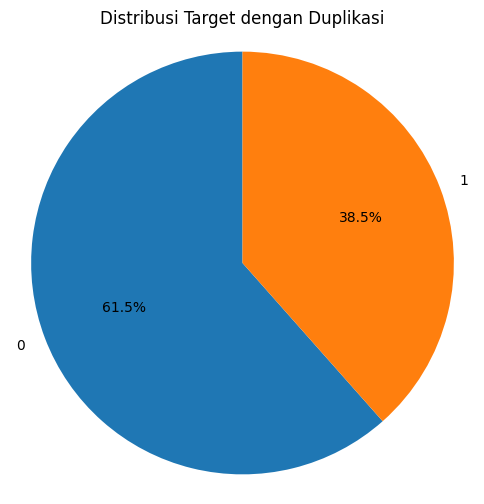

In [141]:
plt.figure(figsize=(6,6))
plt.pie(target_count, labels=target_count.index, autopct='%1.1f%%', startangle=90)
plt.title("Distribusi Target dengan Duplikasi")
plt.axis('equal')
plt.show()

- No Duplicate

In [142]:
target_count_no = no_duplicate['class'].value_counts()
target_count_no

class
0    173
1     78
Name: count, dtype: int64

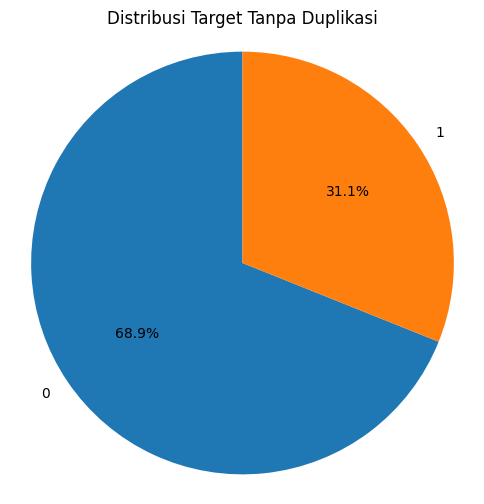

In [143]:
plt.figure(figsize=(6,6))
plt.pie(target_count_no, labels=target_count_no.index, autopct='%1.1f%%', startangle=90)
plt.title("Distribusi Target Tanpa Duplikasi")
plt.axis('equal')
plt.show()

#### *b. Inspeksi Distribusi Kelas Fitur*

- Dataset Asli

In [144]:
def check_value(cols, top_n=2):
    for col in cols:
        print(f"Kolom: {col}")
        print(dataset[col].value_counts().head(top_n))  
        print("\n")

check_value(all_fitur, top_n=3)

Kolom: Age
Age
35    30
48    28
43    25
Name: count, dtype: int64


Kolom: Gender
Gender
0    328
1    192
Name: count, dtype: int64


Kolom: Polyuria
Polyuria
1    262
0    258
Name: count, dtype: int64


Kolom: Polydipsia
Polydipsia
1    287
0    233
Name: count, dtype: int64


Kolom: sudden weight loss
sudden weight loss
1    303
0    217
Name: count, dtype: int64


Kolom: weakness
weakness
0    305
1    215
Name: count, dtype: int64


Kolom: Polyphagia
Polyphagia
1    283
0    237
Name: count, dtype: int64


Kolom: Genital thrush
Genital thrush
1    404
0    116
Name: count, dtype: int64


Kolom: visual blurring
visual blurring
1    287
0    233
Name: count, dtype: int64


Kolom: Itching
Itching
1    267
0    253
Name: count, dtype: int64


Kolom: Irritability
Irritability
1    394
0    126
Name: count, dtype: int64


Kolom: delayed healing
delayed healing
1    281
0    239
Name: count, dtype: int64


Kolom: partial paresis
partial paresis
1    296
0    224
Name: count, dtype: in

- No Duplicate

In [145]:
def check_value(cols, top_n=2):
    for col in cols:
        print(f"Kolom: {col}")
        print(no_duplicate[col].value_counts().head(top_n))  
        print("\n")

check_value(all_fitur, top_n=3)

Kolom: Age
Age
35    15
48    11
40    11
Name: count, dtype: int64


Kolom: Gender
Gender
0    160
1     91
Name: count, dtype: int64


Kolom: Polyuria
Polyuria
0    132
1    119
Name: count, dtype: int64


Kolom: Polydipsia
Polydipsia
1    127
0    124
Name: count, dtype: int64


Kolom: sudden weight loss
sudden weight loss
1    147
0    104
Name: count, dtype: int64


Kolom: weakness
weakness
0    159
1     92
Name: count, dtype: int64


Kolom: Polyphagia
Polyphagia
1    134
0    117
Name: count, dtype: int64


Kolom: Genital thrush
Genital thrush
1    184
0     67
Name: count, dtype: int64


Kolom: visual blurring
visual blurring
1    140
0    111
Name: count, dtype: int64


Kolom: Itching
Itching
0    127
1    124
Name: count, dtype: int64


Kolom: Irritability
Irritability
1    180
0     71
Name: count, dtype: int64


Kolom: delayed healing
delayed healing
1    126
0    125
Name: count, dtype: int64


Kolom: partial paresis
partial paresis
1    139
0    112
Name: count, dtype: in

### 8. Bivariate Analysis

#### *a. Inspeksi Distribusi Fitur Berdasarkan Target*

- Dataset Asli

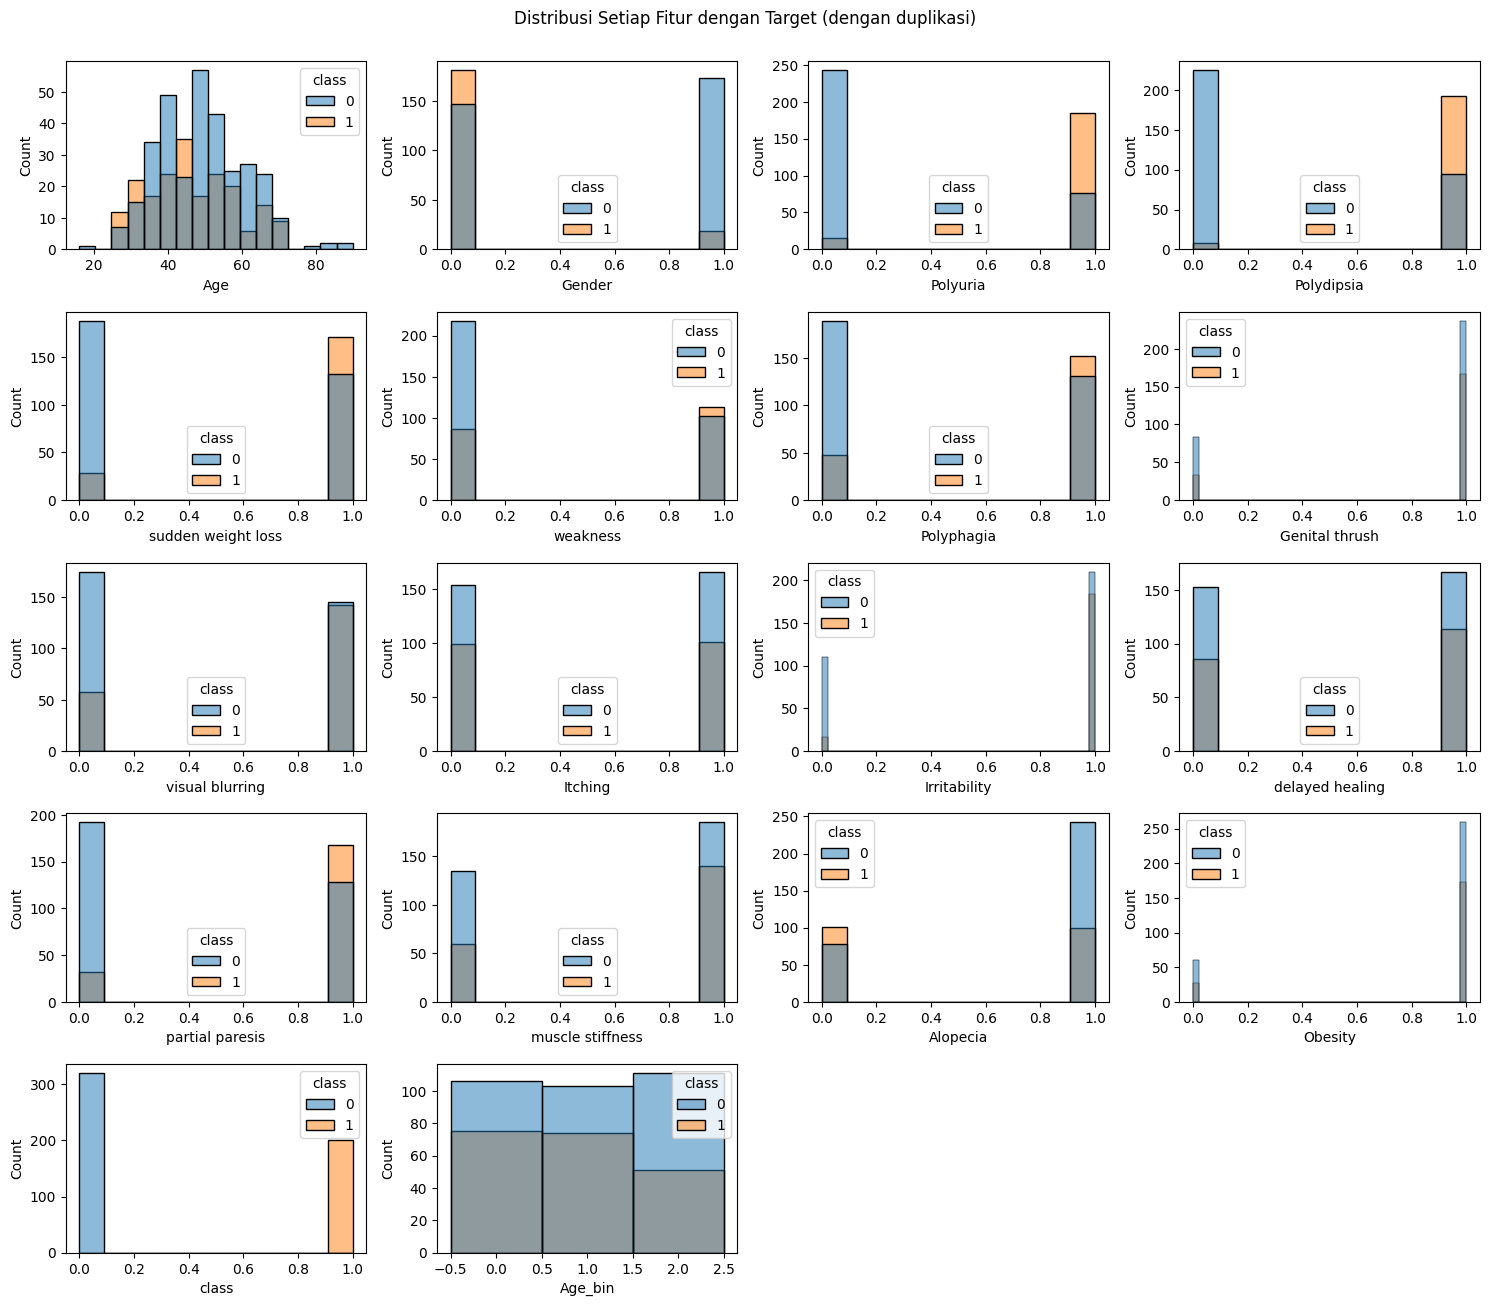

In [146]:
plt.figure(figsize=(15, 13))
for i, col in enumerate(dataset):
    plt.subplot(5, 4, i+1)
    sns.histplot(x=dataset[col], hue=dataset['class'])

plt.suptitle("Distribusi Setiap Fitur dengan Target (dengan duplikasi)", y=1.001)
plt.tight_layout()
plt.show()

- No Duplicate

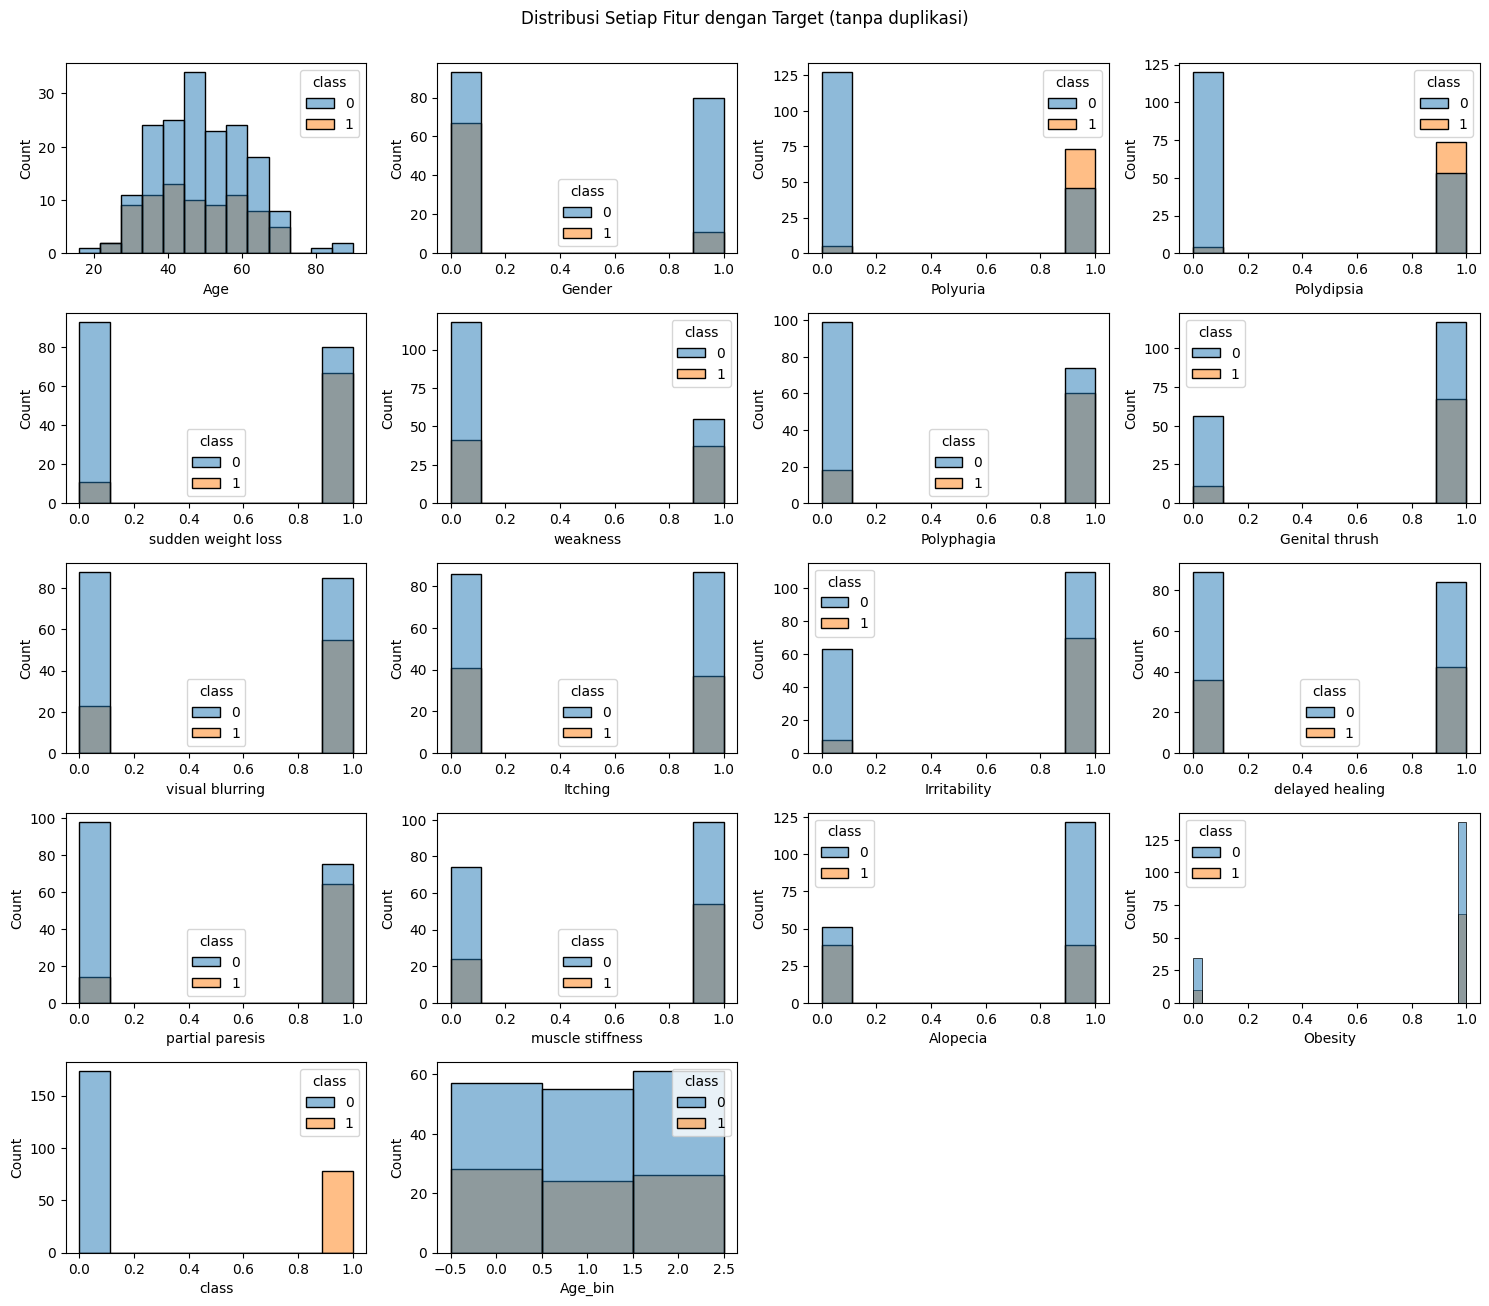

In [147]:
plt.figure(figsize=(15, 13))
for i, col in enumerate(no_duplicate):
    plt.subplot(5, 4, i+1)
    sns.histplot(x=no_duplicate[col], hue=no_duplicate['class'])

plt.suptitle("Distribusi Setiap Fitur dengan Target (tanpa duplikasi)", y=1.001)
plt.tight_layout()
plt.show()

### 9. Multivariate Analysis

#### *a. Inspeksi Hubungan Antar Variabel Berdasarkan Target*

- Dataset Asli

In [148]:
# sns.pairplot(data=dataset, hue=["class"])

- No Duplicate

In [149]:
# sns.pairplot(data=no_duplicate, hue=["class"])

### 10. Inspeksi Korelasi

#### *a. Mutual Information*

In [150]:
def mutual_information(X, y):
    joint_prob = pd.crosstab(X, y, normalize=True)

    px = joint_prob.sum(axis=1)
    py = joint_prob.sum(axis=0)

    mi = 0
    for i in joint_prob.index:
        for j in joint_prob.columns:
            pxy = joint_prob.loc[i, j]
            if pxy > 0:
                mi += pxy * np.log(pxy / (px[i] * py[j]))
    return mi

mi_scores = []
for col in no_duplicate.drop("class", axis=1).columns:
    mi_val = mutual_information(no_duplicate[col], no_duplicate["class"])
    mi_scores.append((col, mi_val))

mi_df = pd.DataFrame(mi_scores, columns=["Feature", "Mutual Information"])
mi_df = mi_df.sort_values(by="Mutual Information", ascending=False)

In [151]:
mi_df

,Feature,Mutual Information
2,Polyuria,0.218647
3,Polydipsia,0.205537
0,Age,0.105855
4,sudden weight loss,0.076179
12,partial paresis,0.069466
1,Gender,0.052650
6,Polyphagia,0.052455
10,Irritability,0.040892
8,visual blurring,0.020354
7,Genital thrush,0.019795


C:\Users\MyPC PRO L5V\AppData\Local\Temp\ipykernel_16416\2504531466.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Mutual Information", y="Feature", data=mi_df, palette="viridis")


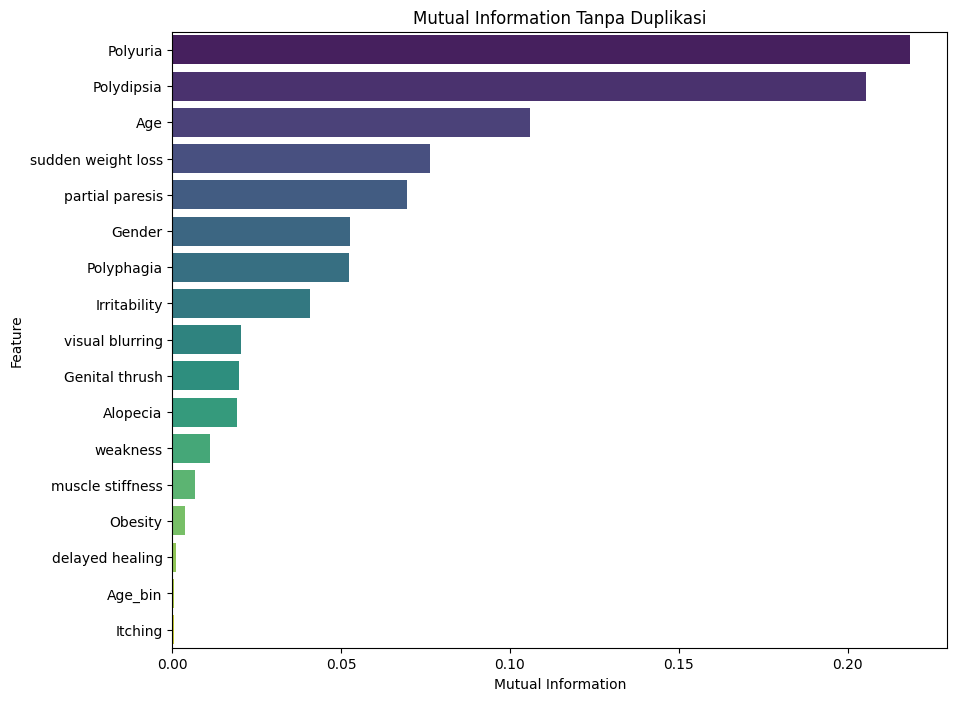

In [152]:
plt.figure(figsize=(10,8))
sns.barplot(x="Mutual Information", y="Feature", data=mi_df, palette="viridis")
plt.title("Mutual Information Tanpa Duplikasi")
plt.xlabel("Mutual Information")
plt.ylabel("Feature")
plt.show()

#### *b. Method Kendall*

In [153]:
kendall_cols = all_fitur + ['class']
data_for_kendall = no_duplicate[kendall_cols].copy()

def kendall_method(x, y):
    concordant = 0
    disconcordant = 0
    n = len(x)

    for i in range(n - 1):
        for j in range(i+1, n):

            x_diff = x[i] - x[j]
            y_diff = y[i] - y[j]

            if x_diff * y_diff > 0:
                concordant += 1
            if x_diff * y_diff < 0:
                disconcordant += 1

    if (concordant - disconcordant) == 0:
        return 0
    
    return (concordant - disconcordant) / (concordant + disconcordant)

n_cols = len(kendall_cols)
kendall_metrix = np.zeros((n_cols, n_cols))

for i in range(n_cols):
    for j in range(n_cols):
        col_i = data_for_kendall.iloc[:, i].values
        col_j = data_for_kendall.iloc[:, j].values
        tau = kendall_method(col_i, col_j)
        kendall_metrix[i, j] = abs(tau)

kendall_df = pd.DataFrame(kendall_metrix, index=kendall_cols, columns=kendall_cols)

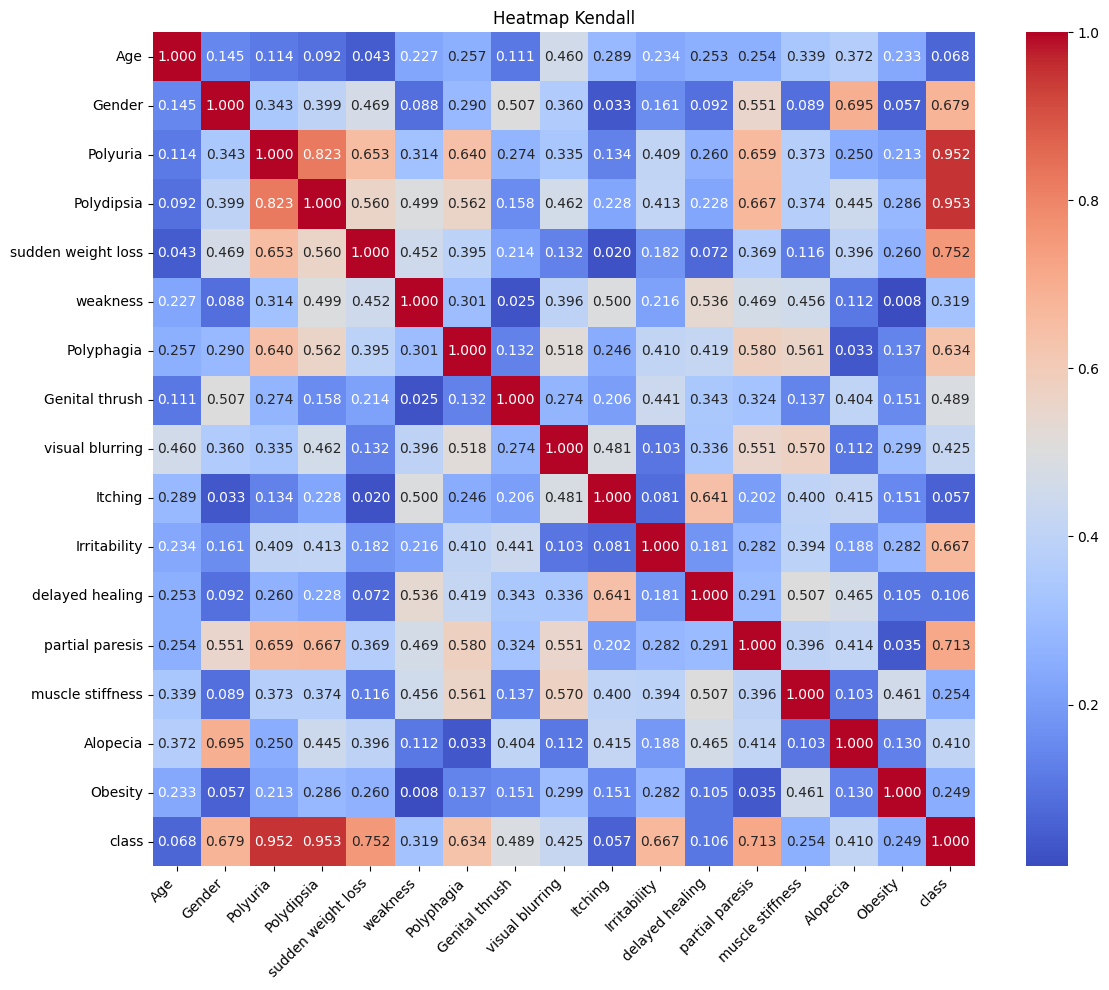

In [154]:
plt.figure(figsize=(12, 10))
sns.heatmap(kendall_df, annot=True, cmap='coolwarm', fmt='.3f')
plt.title("Heatmap Kendall")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

#### *c. Method Chi Square*

In [155]:
def chi_square_test(col, target):
    table = pd.crosstab(col, target)
    observed = table.values
    total = observed.sum()

    row_sum = observed.sum(axis=1).reshape(-1,1)
    col_sum = observed.sum(axis=0).reshape(1,-1)
    expected = row_sum.dot(col_sum) / total

    chi2 = ((observed - expected)**2 / expected).sum()
    dof = (observed.shape[0] - 1) * (observed.shape[1] - 1)
    return chi2, dof

categorical_cols = no_duplicate.drop("class", axis=1).columns

results = []  
for col in categorical_cols:
    chi2, dof = chi_square_test(no_duplicate[col], no_duplicate["class"])
    results.append((col, chi2, dof))

results_dataset = pd.DataFrame(results, columns=["Feature", "Chi2", "DOF"])
print(results_dataset.sort_values(by="Chi2", ascending=False))

               Feature       Chi2  DOF
2             Polyuria  96.793248    1
3           Polydipsia  88.745311    1
0                  Age  45.380941   50
4   sudden weight loss  34.837922    1
12     partial paresis  32.581714    1
6           Polyphagia  25.192270    1
1               Gender  24.029818    1
10        Irritability  18.136420    1
8      visual blurring   9.962622    1
14            Alopecia   9.842616    1
7       Genital thrush   9.167992    1
5             weakness   5.666626    1
13    muscle stiffness   3.255709    1
15             Obesity   1.736088    1
11     delayed healing   0.602073    1
16             Age_bin   0.213551    2
9              Itching   0.175077    1


C:\Users\MyPC PRO L5V\AppData\Local\Temp\ipykernel_16416\3647599249.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Chi2", y="Feature", data=results_dataset.sort_values(by="Chi2", ascending=False), palette="magma")


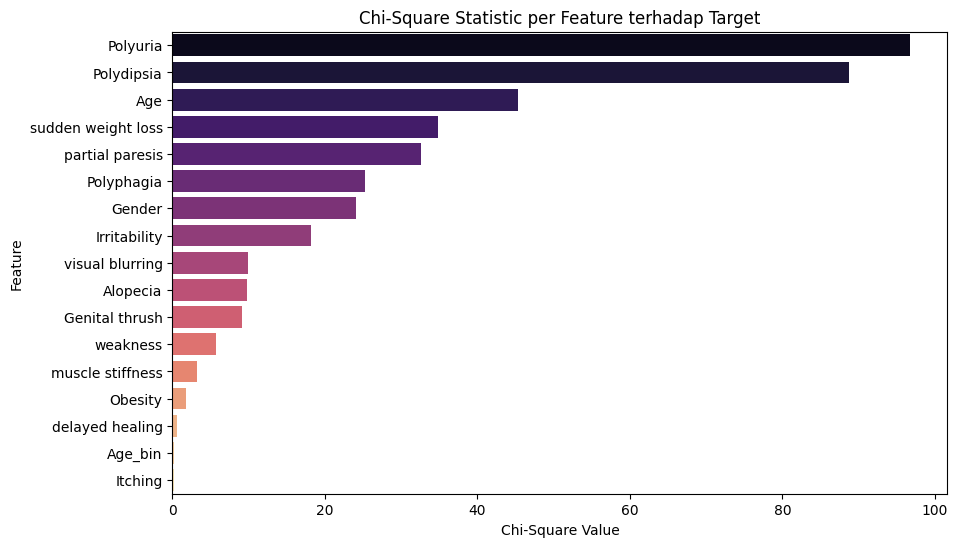

In [156]:
plt.figure(figsize=(10,6))
sns.barplot(x="Chi2", y="Feature", data=results_dataset.sort_values(by="Chi2", ascending=False), palette="magma")
plt.title("Chi-Square Statistic per Feature terhadap Target")
plt.xlabel("Chi-Square Value")
plt.ylabel("Feature")
plt.show()

### 11. Inspeksi Outlier

<Axes: xlabel='class', ylabel='Age_bin'>

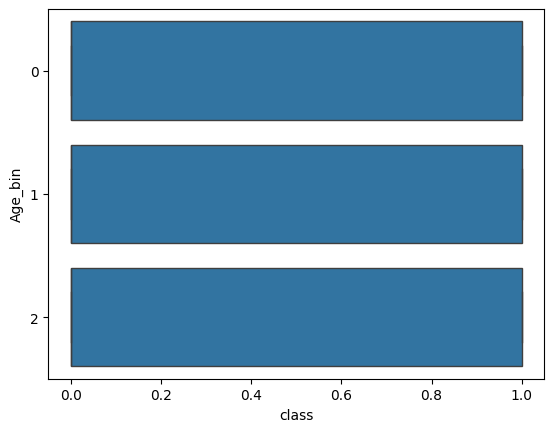

In [157]:
sns.boxplot(data=no_duplicate, x="class", y="Age_bin")

### 12. Kesimpulan Analisis

## ***B. Feature Selection***

In [158]:
feature_cols = ['Age_bin', 'Gender', 'Polyuria', 'Polydipsia', 'sudden weight loss', 'weakness', 'Polyphagia', 'Genital thrush', 'visual blurring', 'Itching', 'Irritability', 'delayed healing', 'partial paresis', 'muscle stiffness', 'Alopecia', 'Obesity']

## ***D. Splitting Dataset***

In [159]:
# def stratified_split(dataset, target_column, training_size=0.8, random_state=42):
#     np.random.seed(random_state)
#     train_list, test_list = [], []

#     for class_value in dataset[target_column].unique():
#         class_data = dataset[dataset[target_column] == class_value]
#         class_data = class_data.sample(frac=1, random_state=random_state)

#         split_idx = int(len(class_data) * training_size)
#         train_list.append(class_data.iloc[:split_idx])
#         test_list.append(class_data.iloc[split_idx:])

#     train_set = pd.concat(train_list).reset_index(drop=True)
#     test_set = pd.concat(test_list).reset_index(drop=True)
#     return train_set, test_set

# dataset_training, dataset_testing = stratified_split(no_duplicate, "class")

def stratified_split(dataset, target_column, training_size=0.8, random_state=42, min_test_per_class=1, shuffle_output=True):
    train_parts, test_parts = [], []

    for cls, part in dataset.groupby(target_column):
        part = part.sample(frac=1.0, random_state=random_state)  # shuffle per kelas
        n_train = int(len(part) * training_size)
        # Pastikan test set masih punya sampel
        if len(part) - n_train < min_test_per_class and len(part) > min_test_per_class:
            n_train = len(part) - min_test_per_class
        train_parts.append(part.iloc[:n_train])
        test_parts.append(part.iloc[n_train:])

    train_set = pd.concat(train_parts, axis=0).reset_index(drop=True)
    test_set  = pd.concat(test_parts, axis=0).reset_index(drop=True)

    if shuffle_output:
        train_set = train_set.sample(frac=1.0, random_state=random_state+1).reset_index(drop=True)
        test_set  = test_set.sample(frac=1.0, random_state=random_state+2).reset_index(drop=True)

    return train_set, test_set

dataset_training, dataset_testing = stratified_split(no_duplicate, "class")


## ***E. Data Sampling***

In [160]:
# def smote_oversample(X, y, k=5, random_state=42):
#     np.random.seed(random_state)

#     minority_class = np.bincount(y).argmin()
#     X_minor = X[y == minority_class]
#     y_minor = y[y == minority_class]

#     n_minor = len(X_minor)
#     n_major = len(y) - n_minor
#     n_synthetic = n_major - n_minor

#     if n_synthetic <= 0:
#         return X, y
    
#     synthetic_samples = []

#     for _ in range(n_synthetic):
#         idx = np.random.randint(0, n_minor)
#         sample = X_minor[idx]

#         distances = np.linalg.norm(X_minor - sample, axis=1)
#         distances[idx] = np.inf

#         neighbor_indices = np.argsort(distances)[:k]
#         neighbor_idx = np.random.choice(neighbor_indices)
#         neighbor = X_minor[neighbor_idx]

#         diff = neighbor - sample
#         gap = np.random.rand()
#         synthetic = sample + gap * diff
#         synthetic_samples.append(synthetic)

#     X_new = np.vstack([X, synthetic_samples])
#     y_new = np.hstack([y, np.full(n_synthetic, minority_class)])

#     return X_new, y_new

In [161]:
# X_train_num = dataset_training[feature_cols].to_numpy()
# y_train = dataset_training['class'].to_numpy()

# # Terapkan SMOTE
# X_train_smote, y_train_smote = smote_oversample(X_train_num, y_train, k=5)

# print("Sebelum SMOTE:", np.bincount(y_train))
# print("Sesudah SMOTE:", np.bincount(y_train_smote))

In [162]:
target_count = dataset_training['class'].value_counts()
target_count

class
0    138
1     62
Name: count, dtype: int64

## ***F. Feature Target Declaration***

In [163]:
X_train = dataset_training[feature_cols].to_numpy()
X_test = dataset_testing[feature_cols].to_numpy()
y_train = dataset_training['class'].to_numpy()
y_test = dataset_testing['class'].to_numpy()

In [164]:
X_train

array([[1, 0, 0, ..., 1, 1, 1],
       [1, 0, 1, ..., 1, 1, 0],
       [0, 0, 1, ..., 1, 0, 1],
       ...,
       [2, 0, 0, ..., 1, 0, 1],
       [1, 0, 0, ..., 0, 1, 1],
       [1, 1, 0, ..., 1, 1, 0]], shape=(200, 16))

In [165]:
X_test

array([[0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
       [0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1],
       [0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1],
       [2, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0],
       [0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1],
       [2, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1],
       [2, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0],
       [2, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1],
       [0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0],
       [2, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1],
       [1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1],
       [0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0],
       [2, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0],
       [2, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1],
       [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1],
       [1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1],
       [1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1],
       [1, 0, 1, 1, 1, 1, 1, 1,

In [166]:
print("X_train:", X_train.shape, "y_train:", y_train.shape)
# harus (n_samples, n_features) dan (n_samples,)

X_train: (200, 16) y_train: (200,)


## **III. Modeling**

## ***A. Model Application***

### 1. Model with Class

In [167]:
class TreeEnsemble:
    """
    Parameter penting:
      - max_depth, min_samples_split, min_samples_leaf, min_impurity_decrease
      - criterion: "entropy" atau "gini"
      - n_trees, sample_ratio, feature_ratio (untuk ensemble; feature_ratio diterapkan PER NODE)
      - random_state: reproducibility
      - feature_names: opsional untuk print/plot
    """

    def __init__(self,
                 max_depth=5,
                 feature_names=None,
                 mode="single",
                 n_trees=10,
                 sample_ratio=0.8,
                 feature_ratio=0.8,
                 criterion="entropy",
                 min_samples_split=2,
                 min_samples_leaf=1,
                 min_impurity_decrease=0.0,
                 random_state=None):
        self.max_depth = max_depth
        self.feature_names = feature_names
        self.mode = mode
        self.n_trees = n_trees
        self.sample_ratio = sample_ratio
        self.feature_ratio = feature_ratio
        self.criterion = criterion
        self.min_samples_split = min_samples_split
        self.min_samples_leaf = min_samples_leaf
        self.min_impurity_decrease = min_impurity_decrease
        self.rng = np.random.default_rng(random_state)

        self.trees = None        # single: dict; ensemble: list[dict]
        self.classes_ = None     # array objek label asli (urutan stabil)
        self._label_to_index = None  # dict: label -> idx (int)

    # ============== helpers ==============

    @staticmethod
    def _stable_unique(arr):
        """Unique dengan urutan kemunculan pertama, tanpa sorting (aman untuk campuran tipe)."""
        seen = {}
        out = []
        for v in arr:
            if v not in seen:
                seen[v] = True
                out.append(v)
        return np.array(out, dtype=object)

    def _y_to_index(self, y_raw):
        """Map label asli -> indeks int 0..K-1 sesuai self.classes_ (urutan stabil)."""
        idx = np.empty_like(y_raw, dtype=int)
        # vectorized mapping via loop (hash lookup)
        for i, v in enumerate(y_raw):
            idx[i] = self._label_to_index[v]
        return idx

    def _impurity(self, y_idx):
        counts = np.bincount(y_idx, minlength=len(self.classes_))
        p = counts / counts.sum()
        if self.criterion == "gini":
            return 1.0 - np.sum(p ** 2)
        return -np.sum(p * np.log2(p + 1e-15))  # entropy

    def _information_gain(self, parent_y, left_y, right_y):
        n = len(parent_y)
        if n == 0:
            return 0.0
        return self._impurity(parent_y) - (
            (len(left_y) / n) * self._impurity(left_y) +
            (len(right_y) / n) * self._impurity(right_y)
        )

    # ============== core building blocks ==============

    def _leaf_value(self, y_idx):
        """Leaf menyimpan class_idx dan vector proba (panjang = n_classes)."""
        counts = np.bincount(y_idx, minlength=len(self.classes_)).astype(float)
        proba_vec = counts / counts.sum()
        class_idx = int(np.argmax(proba_vec))
        return {"leaf": True, "class_idx": class_idx, "split": None, "feature": None, "proba": proba_vec}

    def _best_split_for_feature(self, x_col, y_idx):
        """
        Cari threshold terbaik untuk satu fitur dengan midpoint antar nilai unik terurut.
        Return (threshold, gain); kalau tak ada yang valid -> (None, 0.0).
        """
        order = np.argsort(x_col, kind="mergesort")
        x_sorted = x_col[order]
        y_sorted = y_idx[order]

        vals = np.unique(x_sorted)
        if vals.size <= 1:
            return None, 0.0

        thresholds = (vals[:-1] + vals[1:]) / 2.0
        best_gain, best_thr = 0.0, None

        for thr in thresholds:
            left_mask = x_sorted <= thr
            right_mask = ~left_mask
            if left_mask.sum() < self.min_samples_leaf or right_mask.sum() < self.min_samples_leaf:
                continue
            gain = self._information_gain(y_sorted, y_sorted[left_mask], y_sorted[right_mask])
            if gain > best_gain:
                best_gain, best_thr = gain, thr

        return best_thr, best_gain

    def _build_tree(self, X, y_idx, depth=0, is_rf=False):
        """
        Node internal: {"leaf": False, "feature": int, "split": float, "left": node, "right": node}
        Leaf:          {"leaf": True, "class_idx": int, "proba": np.array}
        """
        n_samples, n_features = X.shape

        # stopping
        if (depth >= self.max_depth or
            n_samples < self.min_samples_split or
            n_features == 0 or
            np.unique(y_idx).size == 1):
            return self._leaf_value(y_idx)

        # kandidat fitur per node (RF) atau semua fitur (single)
        if is_rf:
            m_try = max(1, int(self.feature_ratio * n_features))
            cand_features = self.rng.choice(n_features, size=m_try, replace=False)
        else:
            cand_features = np.arange(n_features)

        best_gain, best_split, best_feat = 0.0, None, None

        for f in cand_features:
            thr, gain = self._best_split_for_feature(X[:, f], y_idx)
            if gain > best_gain:
                best_gain, best_split, best_feat = gain, thr, f

        if best_feat is None or best_gain <= self.min_impurity_decrease:
            return self._leaf_value(y_idx)

        left_mask = X[:, best_feat] <= best_split
        right_mask = ~left_mask

        left = self._build_tree(X[left_mask], y_idx[left_mask], depth + 1, is_rf=is_rf)
        right = self._build_tree(X[right_mask], y_idx[right_mask], depth + 1, is_rf=is_rf)

        return {"leaf": False, "feature": int(best_feat), "split": float(best_split), "left": left, "right": right}

    # ============== fit / predict ==============

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y).ravel()  # boleh campuran tipe

        # siapkan kelas stabil & mapping label->index
        self.classes_ = self._stable_unique(y)
        self._label_to_index = {lab: i for i, lab in enumerate(self.classes_)}
        y_idx = self._y_to_index(y)  # integer 0..K-1

        if self.feature_names is None:
            self.feature_names = [f"X{j}" for j in range(X.shape[1])]

        if self.mode == "single":
            self.trees = self._build_tree(X, y_idx, depth=0, is_rf=False)
        else:
            forest = []
            n_boot = max(1, int(len(X) * self.sample_ratio))
            for _ in range(self.n_trees):
                idx = self.rng.choice(len(X), size=n_boot, replace=True)
                root = self._build_tree(X[idx], y_idx[idx], depth=0, is_rf=True)
                forest.append(root)
            self.trees = forest
        return self

    def _traverse(self, node, sample):
        while not node.get("leaf", False):
            f = node["feature"]
            if sample[f] <= node["split"]:
                node = node["left"]
            else:
                node = node["right"]
        return node

    def predict_proba(self, X):
        X = np.asarray(X)
        n, C = X.shape[0], len(self.classes_)
        if self.mode == "single":
            out = np.zeros((n, C), dtype=float)
            for i, s in enumerate(X):
                leaf = self._traverse(self.trees, s)
                out[i] = leaf["proba"]
            return out
        # ensemble: soft voting = rata-rata proba
        out = np.zeros((n, C), dtype=float)
        for root in self.trees:
            for i, s in enumerate(X):
                leaf = self._traverse(root, s)
                out[i] += leaf["proba"]
        out /= len(self.trees)
        return out

    def predict(self, X):
        proba = self.predict_proba(X)              # (n, C)
        cls_idx = np.argmax(proba, axis=1)         # pure NumPy
        return self.classes_[cls_idx]              # map balik ke label asli

    # ============== utilities: print / plot / trace ==============

    def print_tree(self, tree=None, depth=0):
        node = (self.trees if self.mode == "single" else (self.trees[0] if tree is None else tree))
        if node.get("leaf", False):
            cls = self.classes_[node["class_idx"]]
            print("  " * depth + f"Predict: {cls}  (proba={np.round(node['proba'],3)})")
            return
        feat = node["feature"]
        name = self.feature_names[feat] if self.feature_names else f"X{feat}"
        print("  " * depth + f"({name}) <= {node['split']:.5f}")
        print("  " * depth + "-> Left:")
        self.print_tree(node["left"], depth + 1)
        print("  " * depth + "-> Right:")
        self.print_tree(node["right"], depth + 1)

    def plot_tree(self, tree=None, x=0.5, y=1.0, dx=0.25, dy=0.12, ax=None, fontsize=11):
        if ax is None:
            fig, ax = plt.subplots(figsize=(18, 22))
        ax.axis("off")
        node = self.trees if self.mode == "single" else (self.trees[0] if tree is None else tree)

        def _plot(n, x, y, dx, dy):
            if n.get("leaf", False):
                cls = self.classes_[n["class_idx"]]
                ax.text(x, y, f"{cls}\n{np.round(n['proba'],3)}",
                        bbox=dict(facecolor="lightblue", alpha=0.6),
                        ha="center", va="center", fontsize=fontsize)
                return
            feat = n["feature"]
            name = self.feature_names[feat] if self.feature_names else f"X{feat}"
            ax.text(x, y, f"{name} ≤ {n['split']:.4f}",
                    bbox=dict(facecolor="lightblue", alpha=0.6),
                    ha="center", va="center", fontsize=fontsize)
            x_l, x_r = x - dx, x + dx
            y_n = y - dy
            ax.plot([x, x_l], [y, y_n], 'k-')
            ax.plot([x, x_r], [y, y_n], 'k-')
            ax.text((x + x_l)/2, (y + y_n)/2, "True", fontsize=fontsize-1)
            ax.text((x + x_r)/2, (y + y_n)/2, "False", fontsize=fontsize-1)
            _plot(n["left"], x_l, y_n, dx/2.0, dy)
            _plot(n["right"], x_r, y_n, dx/2.0, dy)

        _plot(node, x, y, dx, dy)

    def plot_forest(self, num_trees=3):
        if self.mode != "ensemble":
            raise ValueError("plot_forest hanya untuk mode='ensemble'.")
        k = min(num_trees, len(self.trees))
        for i in range(k):
            fig, ax = plt.subplots(figsize=(18, 22))
            self.plot_tree(tree=self.trees[i], ax=ax)
            plt.title(f"Tree {i+1}")
            plt.show()

    def trace_decision_path(self, tree, sample, depth=0):
        """Print jalur keputusan; return class_idx."""
        if tree.get("leaf", False):
            cls = self.classes_[tree["class_idx"]]
            print("  " * depth + f"==> Predict: {cls} | proba={np.round(tree['proba'],3)}")
            return tree["class_idx"]
        feat, split = tree["feature"], tree["split"]
        name = self.feature_names[feat] if self.feature_names else f"X{feat}"
        go_left = sample[feat] <= split
        side = "Left" if go_left else "Right"
        print("  " * depth + f"{name} <= {split:.5f}  -> {side}")
        next_branch = tree["left"] if go_left else tree["right"]
        return self.trace_decision_path(next_branch, sample, depth+1)

    def predict_with_trace(self, X):
        """Ensemble voting pakai NumPy murni (np.bincount)."""
        X = np.asarray(X)
        preds = []
        for i, s in enumerate(X):
            print(f"\nSample {i+1}")
            if self.mode == "single":
                cls_idx = self.trace_decision_path(self.trees, s)
                preds.append(self.classes_[cls_idx])
            else:
                idxs = []
                for j, root in enumerate(self.trees):
                    print(f"\nTree {j+1}")
                    idxs.append(self.trace_decision_path(root, s))
                idxs = np.asarray(idxs, dtype=int)
                counts = np.bincount(idxs, minlength=len(self.classes_))
                maj_idx = int(np.argmax(counts))
                print(f"Majority Vote: {self.classes_[maj_idx]}")
                preds.append(self.classes_[maj_idx])
        return np.array(preds)

### 2. Single Mode

In [168]:
model_tree = TreeEnsemble(
    mode="single",
    max_depth=7,
    criterion="entropy",          # atau "gini"
    min_samples_split=2,
    min_samples_leaf=1,
    min_impurity_decrease=0.0,
    random_state=42,
    feature_names=feature_cols
)

model_tree.fit(X_train, y_train)

y_pred_tree_train = model_tree.predict(X_train)
y_pred_tree_test  = model_tree.predict(X_test)

# kalau perlu probabilitas (untuk thresholding/ROC/PR)
proba_test = model_tree.predict_proba(X_test)  

### 3. Ensemble Mode

In [169]:
model_rf = TreeEnsemble(
    mode="ensemble",
    n_trees=100,
    max_depth=7,
    sample_ratio=0.8,             # bootstrap size
    feature_ratio=0.5,            # subset fitur per node (mis. 0.5 ≈ setengah fitur)
    criterion="gini",             # atau "entropy"
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    feature_names=feature_cols
)

model_rf.fit(X_train, y_train)

y_pred_rf_train = model_rf.predict(X_train)
y_pred_rf_test  = model_rf.predict(X_test)

# probabilitas (soft voting, rata-rata proba semua tree)
proba_rf_test = model_rf.predict_proba(X_test)


## ***B. Model Visualization***

### 1. Distribusi Hasil Prediksi

#### *a. Single Mode*

Distribusi Prediksi Decision Tree Training Model:
0    138
1     62
Name: count, dtype: int64


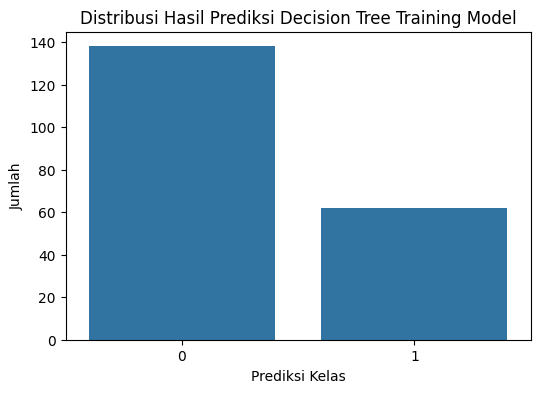

In [170]:
print("Distribusi Prediksi Decision Tree Training Model:")
print(pd.Series(y_pred_tree_train).value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x=y_pred_tree_train)
plt.title("Distribusi Hasil Prediksi Decision Tree Training Model")
plt.xlabel("Prediksi Kelas")
plt.ylabel("Jumlah")
plt.show()

Distribusi Prediksi Decision Tree Testing Model:
0    29
1    22
Name: count, dtype: int64


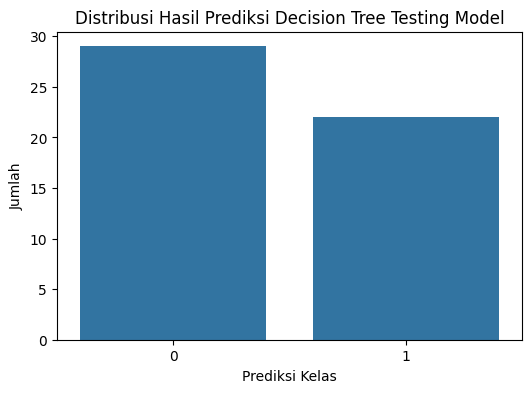

In [171]:
print("Distribusi Prediksi Decision Tree Testing Model:")
print(pd.Series(y_pred_tree_test).value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x=y_pred_tree_test)
plt.title("Distribusi Hasil Prediksi Decision Tree Testing Model")
plt.xlabel("Prediksi Kelas")
plt.ylabel("Jumlah")
plt.show()

#### *b. Ensemble Mode*

Distribusi Prediksi Random Forest Training Model:
0    138
1     62
Name: count, dtype: int64


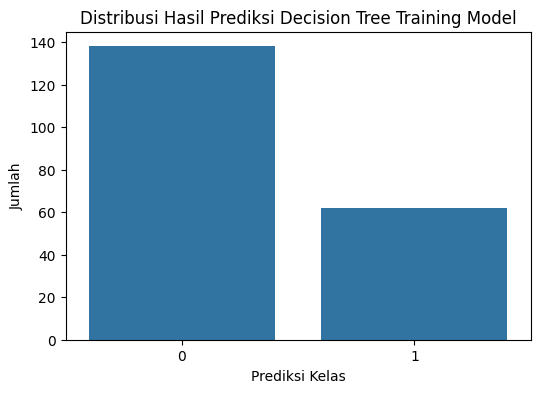

In [172]:
print("Distribusi Prediksi Random Forest Training Model:")
print(pd.Series(y_pred_rf_train).value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x=y_pred_rf_train)
plt.title("Distribusi Hasil Prediksi Decision Tree Training Model")
plt.xlabel("Prediksi Kelas")
plt.ylabel("Jumlah")
plt.show()

Distribusi Prediksi Random Forest Testing Model:
0    32
1    19
Name: count, dtype: int64


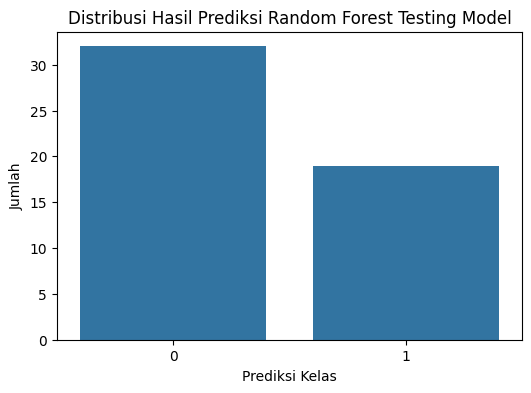

In [173]:
print("Distribusi Prediksi Random Forest Testing Model:")
print(pd.Series(y_pred_rf_test).value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x=y_pred_rf_test)
plt.title("Distribusi Hasil Prediksi Random Forest Testing Model")
plt.xlabel("Prediksi Kelas")
plt.ylabel("Jumlah")
plt.show()

### 3. Pohon Keputusan

#### *a. Tree Visualization*

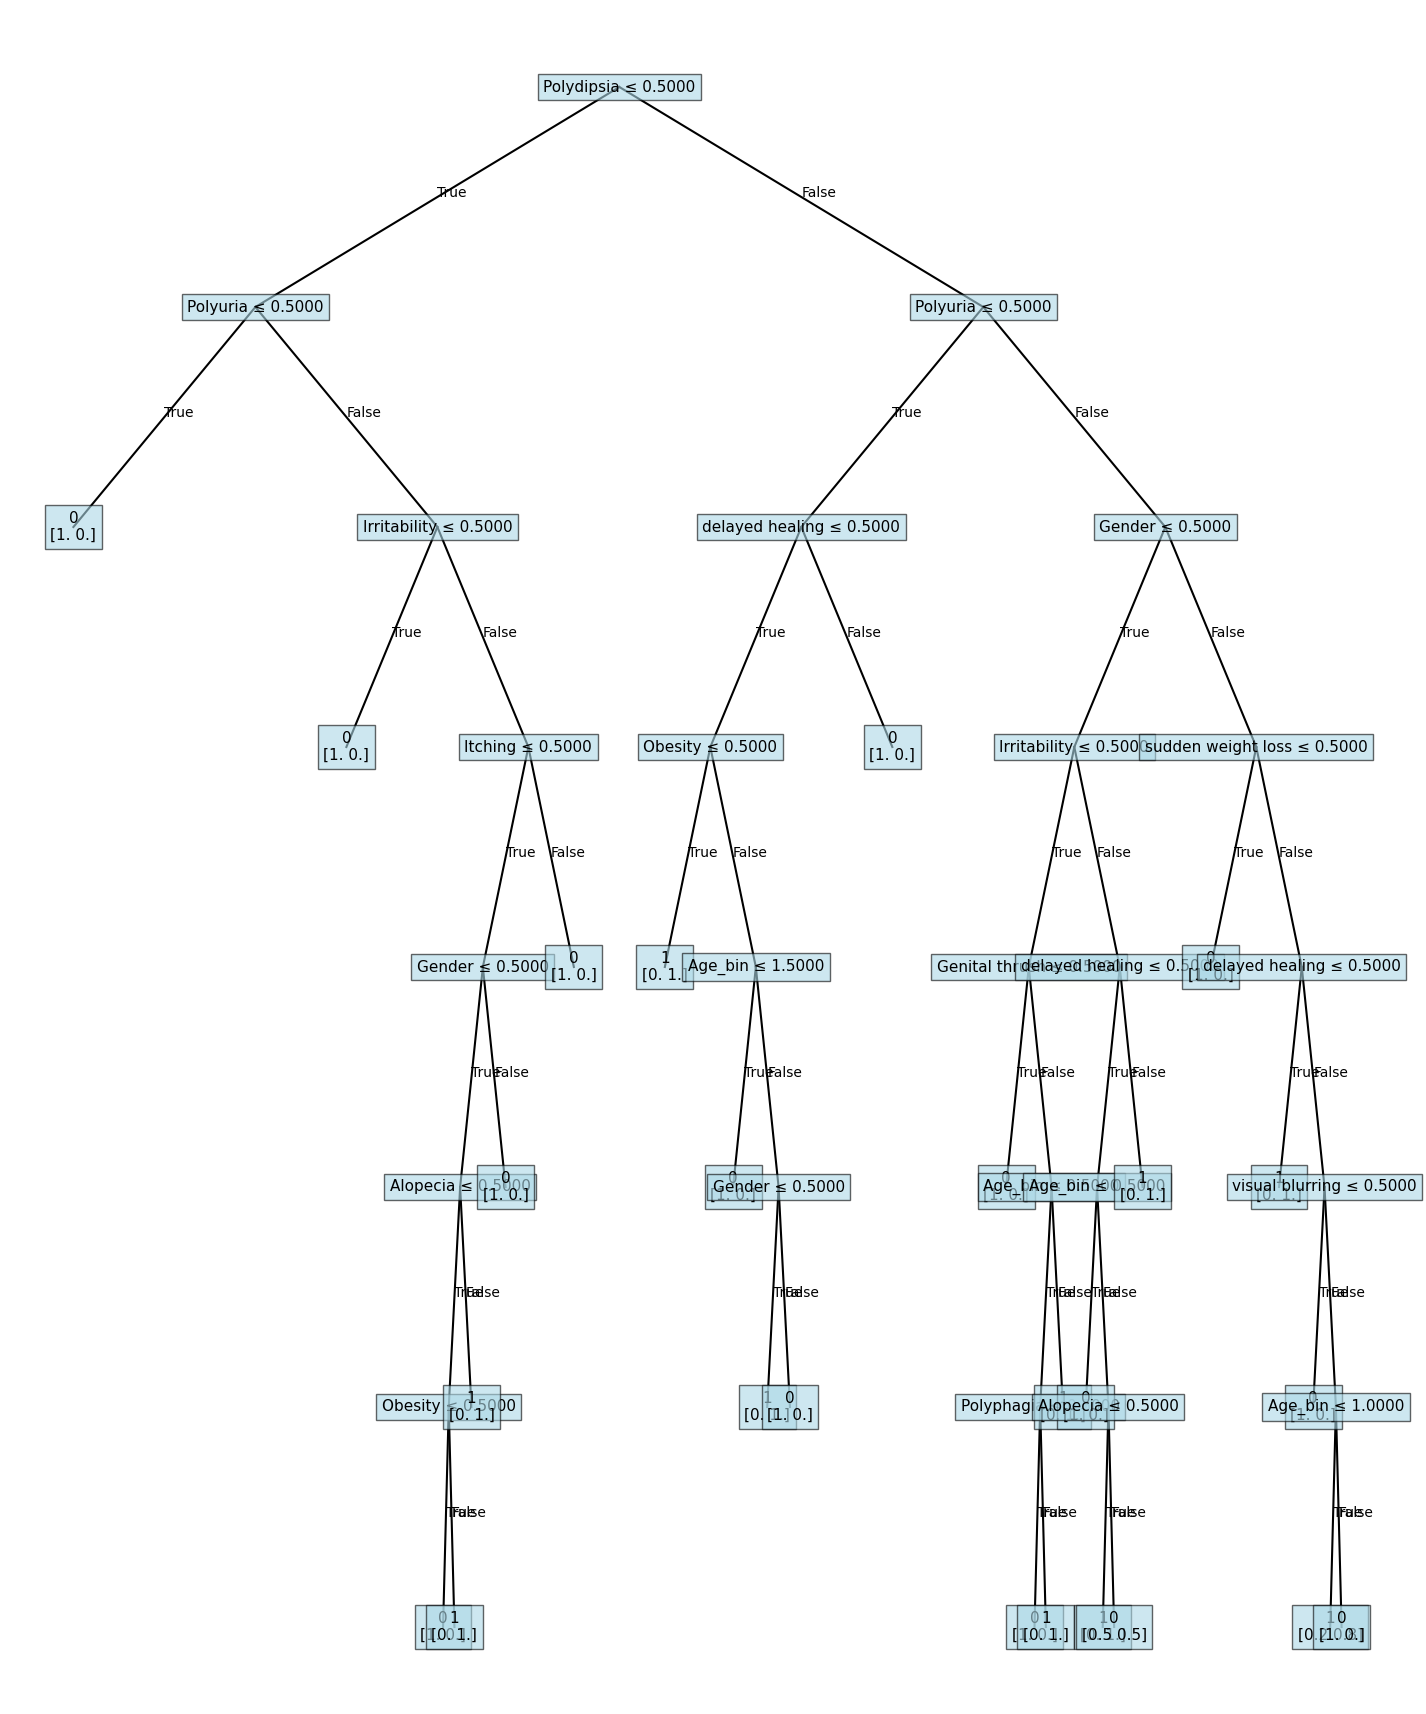

In [174]:
model_tree.plot_tree()

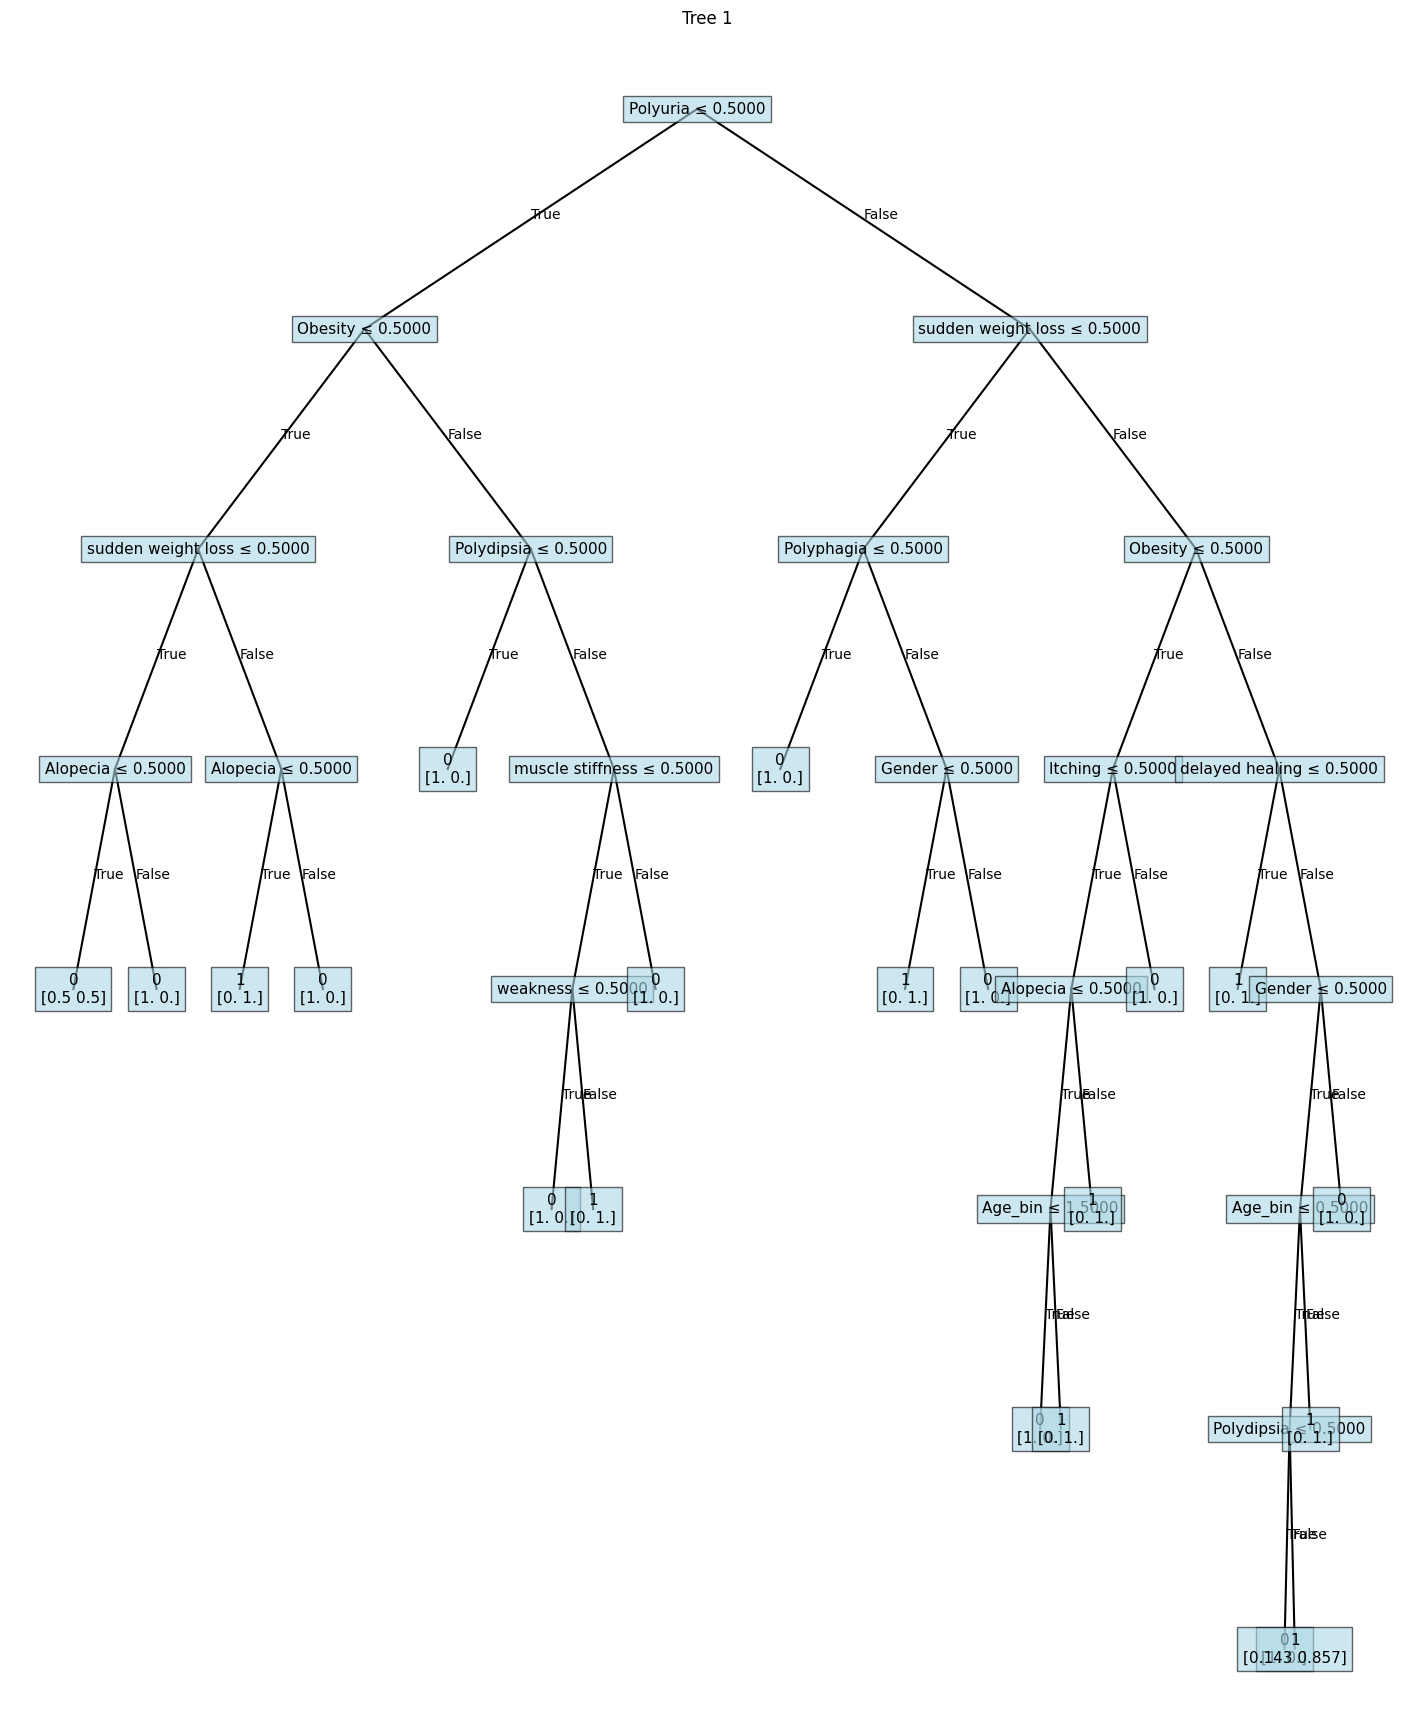

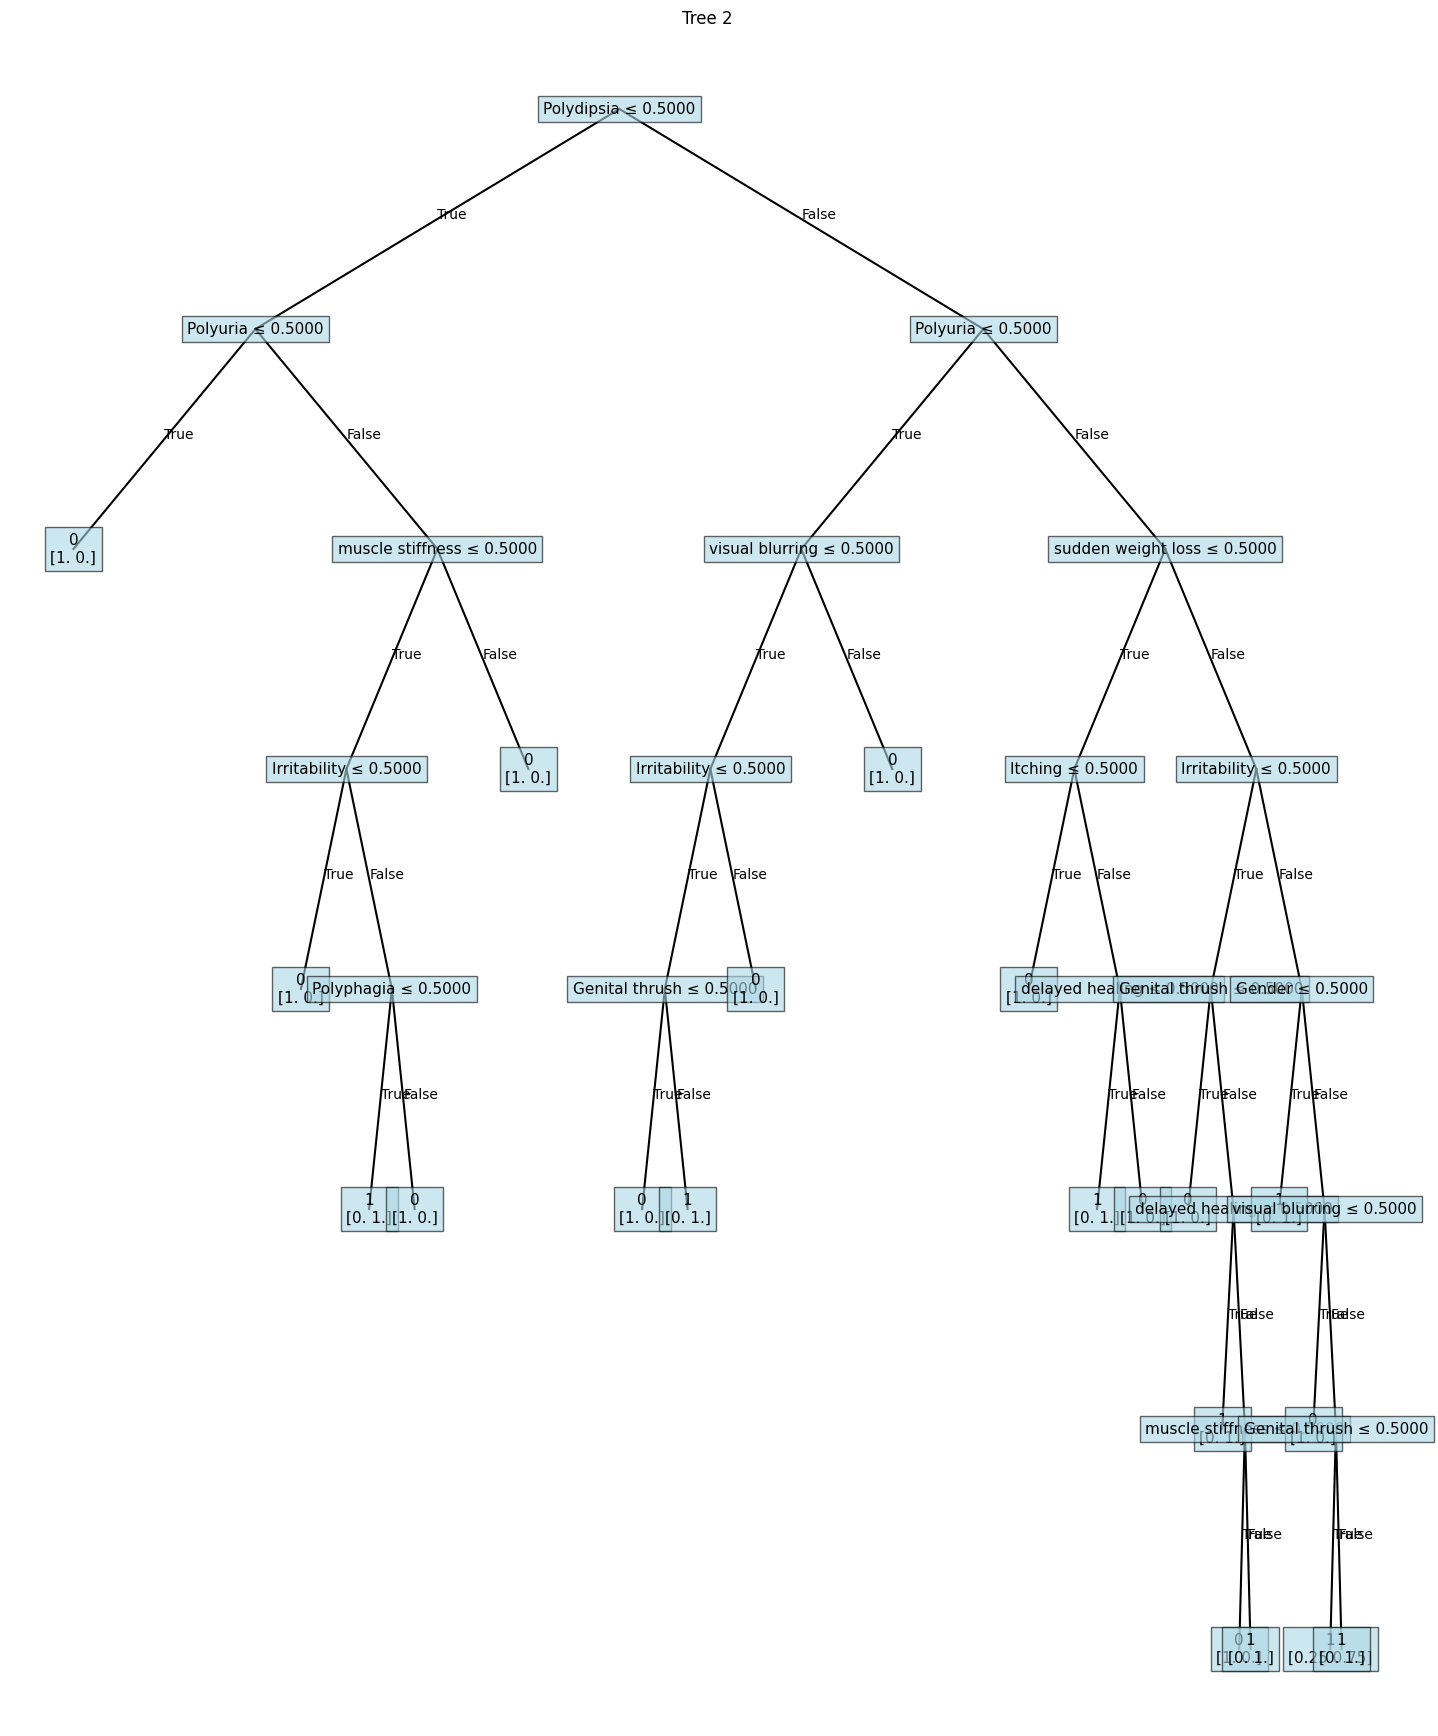

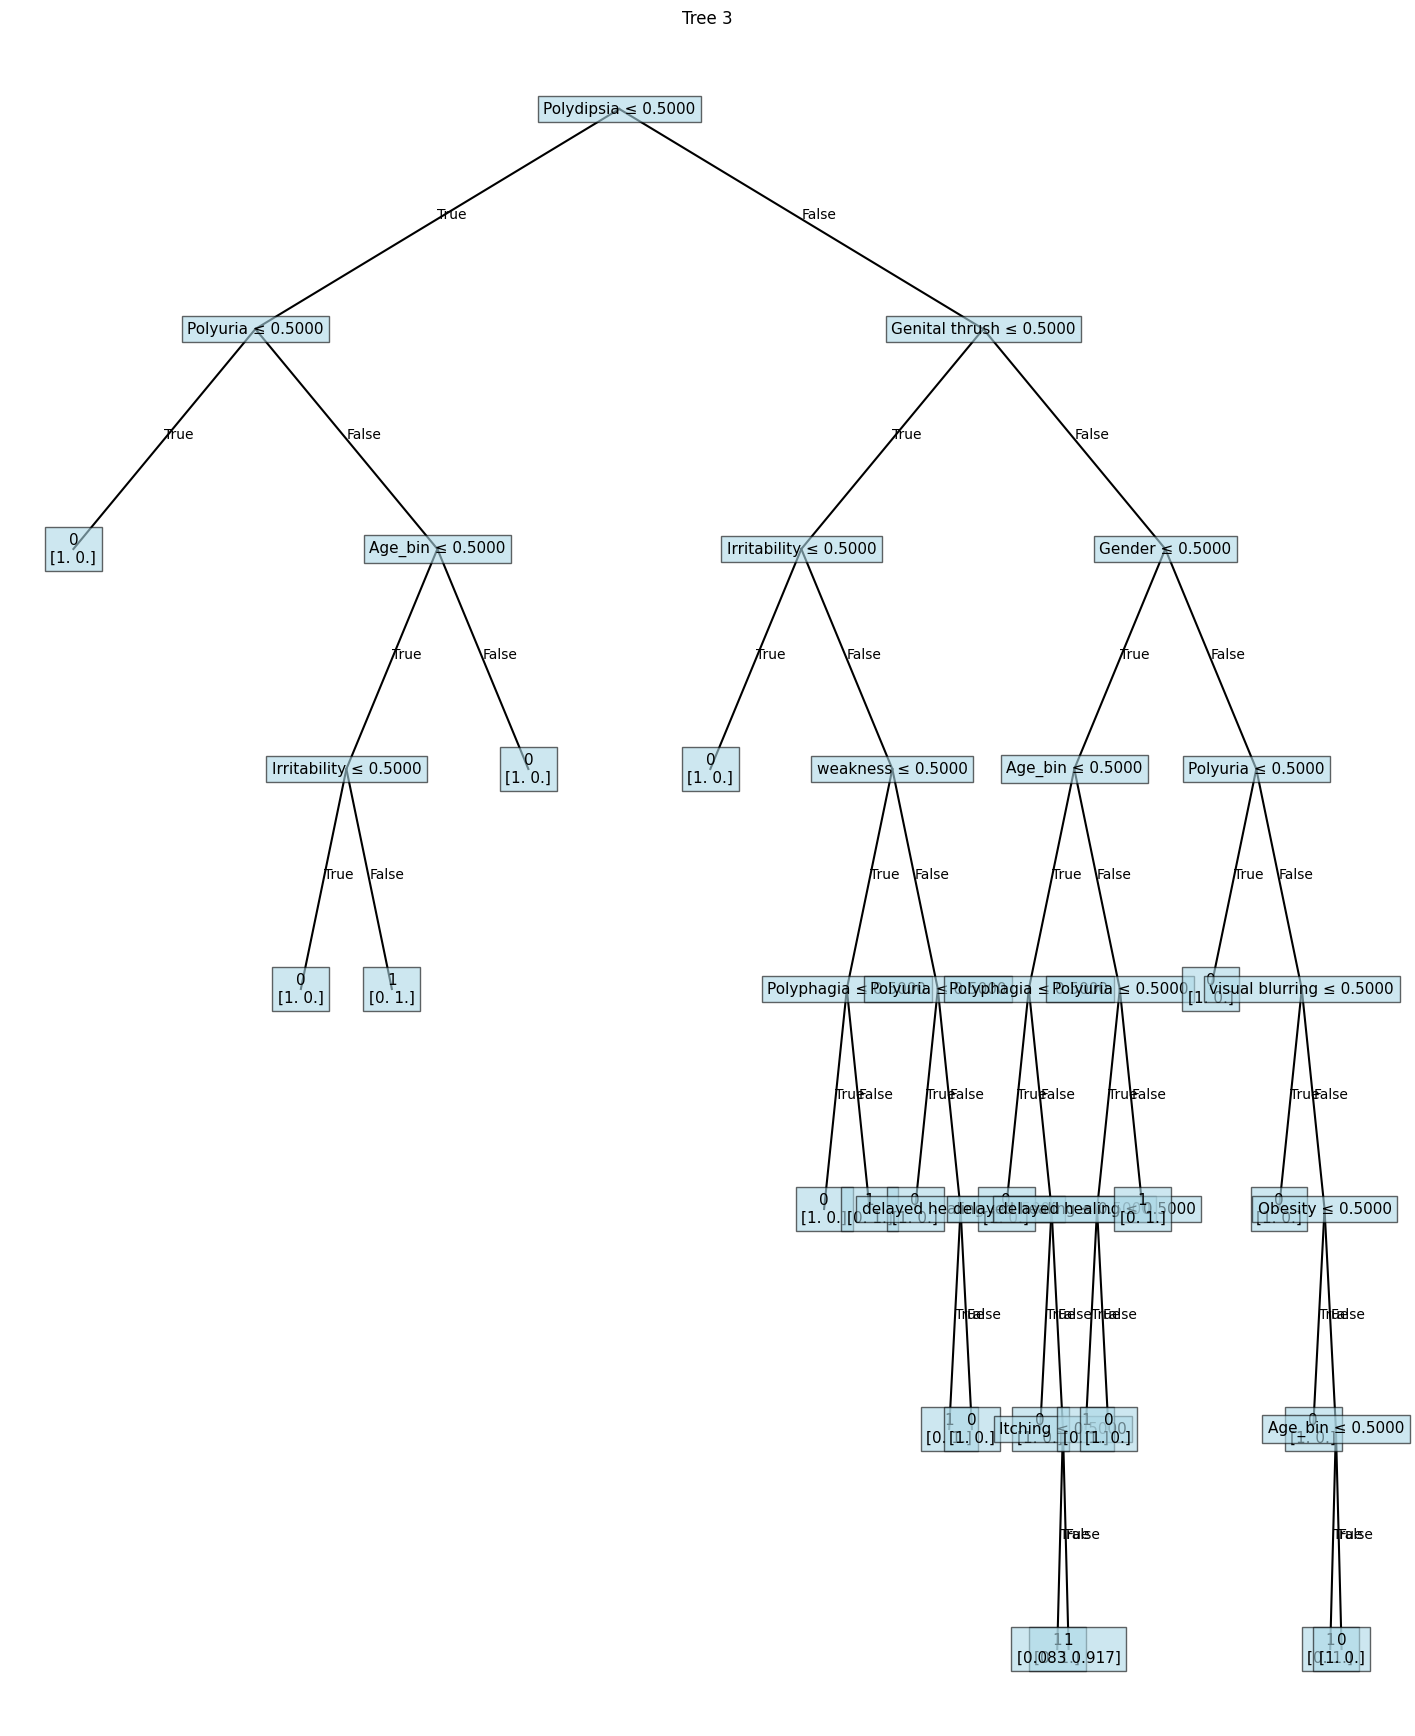

In [175]:
model_rf.plot_forest(num_trees=3)

### *b. Tracing Jalur Keputusan*

In [176]:
model_tree.predict_with_trace(X_test[:3])


Sample 1
Polydipsia <= 0.50000  -> Right
  Polyuria <= 0.50000  -> Right
    Gender <= 0.50000  -> Left
      Irritability <= 0.50000  -> Right
        delayed healing <= 0.50000  -> Right
          ==> Predict: 1 | proba=[0. 1.]

Sample 2
Polydipsia <= 0.50000  -> Left
  Polyuria <= 0.50000  -> Left
    ==> Predict: 0 | proba=[1. 0.]

Sample 3
Polydipsia <= 0.50000  -> Left
  Polyuria <= 0.50000  -> Right
    Irritability <= 0.50000  -> Right
      Itching <= 0.50000  -> Left
        Gender <= 0.50000  -> Right
          ==> Predict: 0 | proba=[1. 0.]


array([1, 0, 0])

## ***C. Model Evaluation***

In [177]:
# --------------------------------------------------------
# Confusion Matrix (umum), Metrics (micro/macro), Evaluator
# --------------------------------------------------------


def _unique_stable(a):
    """Unique dengan urutan kemunculan pertama (stabil terhadap tipe campur)."""
    seen, out = set(), []
    for v in a:
        if v not in seen:
            seen.add(v); out.append(v)
    return np.array(out, dtype=object)


def confusion_matrix_np(y_true, y_pred, labels=None, normalize=None):
    """
    Return M (nC x nC) dgn baris=TRUE, kolom=PRED, dan urutan label.
    normalize: None | 'true' (per baris) | 'pred' (per kolom)
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    if labels is None:
        labels = _unique_stable(np.concatenate([y_true, y_pred]))
    lab2idx = {lab:i for i, lab in enumerate(labels)}
    M = np.zeros((len(labels), len(labels)), dtype=float)
    for t, p in zip(y_true, y_pred):
        M[lab2idx[t], lab2idx[p]] += 1.0


    if normalize == 'true':
        row_sums = M.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1.0
        M = M / row_sums
    elif normalize == 'pred':
        col_sums = M.sum(axis=0, keepdims=True)
        col_sums[col_sums == 0] = 1.0
        M = M / col_sums
    return M, labels


def classification_metrics(y_true, y_pred, average='macro'):
    """
    Hitung accuracy, precision, recall, f1 untuk multi/binary tanpa sklearn.
    average: 'macro' (rata per kelas), 'micro' (agregat global).
    """
    M, labels = confusion_matrix_np(y_true, y_pred)  # counts
    C = len(labels)
    N = M.sum()
    acc = np.trace(M) / N if N > 0 else 0.0


    # per-class P/R/F1
    tp = np.diag(M)
    fp = M.sum(axis=0) - tp
    fn = M.sum(axis=1) - tp


    with np.errstate(divide='ignore', invalid='ignore'):
        prec_c = np.where(tp + fp > 0, tp / (tp + fp), 0.0)
        rec_c  = np.where(tp + fn > 0, tp / (tp + fn), 0.0)
        f1_c   = np.where(prec_c + rec_c > 0, 2*prec_c*rec_c/(prec_c+rec_c), 0.0)


    if average == 'macro':
        precision = prec_c.mean()
        recall    = rec_c.mean()
        f1        = f1_c.mean()
    elif average == 'micro':
        TP = tp.sum()
        FP = fp.sum()
        FN = fn.sum()
        precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
        recall    = TP / (TP + FN) if (TP + FN) > 0 else 0.0
        f1        = (2*precision*recall/(precision+recall)) if (precision+recall) > 0 else 0.0
    else:
        raise ValueError("average harus 'macro' atau 'micro'")


    return {
        "accuracy": float(acc),
        "precision_"+average: float(precision),
        "recall_"+average: float(recall),
        "f1_"+average: float(f1),
        "per_class": {
            "labels": labels,
            "precision": prec_c,
            "recall": rec_c,
            "f1": f1_c
        }
    }


def evaluate_and_plot(y_true, y_pred, title="", average='macro', normalize_cm='true'):
    """
    Satu fungsi untuk TRAIN/TEST:
      - hitung metrics (accuracy + P/R/F1 macro/micro)
      - plot confusion matrix (opsi normalisasi per baris)
    Return: dict metrics
    """
    # metrics (macro & micro sekaligus)
    m_macro = classification_metrics(y_true, y_pred, average='macro')
    m_micro = classification_metrics(y_true, y_pred, average='micro')


    # gabungkan ringkas
    out = {
        "accuracy": m_macro["accuracy"],
        "precision_macro": m_macro["precision_macro"],
        "recall_macro": m_macro["recall_macro"],
        "f1_macro": m_macro["f1_macro"],
        "precision_micro": m_micro["precision_micro"],
        "recall_micro": m_micro["recall_micro"],
        "f1_micro": m_micro["f1_micro"],
    }


    # confusion matrix
    cm, labels = confusion_matrix_np(y_true, y_pred, normalize=normalize_cm)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt=".2f" if normalize_cm else "g",
                cmap="Blues", xticklabels=labels, yticklabels=labels)
    plt.xlabel("Prediksi"); plt.ylabel("Kelas Sebenarnya")
    plt.title(title if title else "Confusion Matrix")
    plt.tight_layout()
    plt.show()


    # tampilkan tabel metrik singkat
    dfm = pd.DataFrame({
        "metric": ["accuracy","precision_macro","recall_macro","f1_macro",
                   "precision_micro","recall_micro","f1_micro"],
        "value":  [out[k] for k in ["accuracy","precision_macro","recall_macro","f1_macro",
                                    "precision_micro","recall_micro","f1_micro"]]
    })
    print(dfm.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
    return out

In [178]:
# --------------------------------------------------------
# Stratified K-Fold (manual) + Cross-Validation evaluator
# --------------------------------------------------------


def _stratified_folds(y, k=5, random_state=42):
    rng = np.random.default_rng(random_state)
    y = np.asarray(y)
    classes = _unique_stable(y)
    idx_per = {c: np.where(y==c)[0] for c in classes}
    folds = [ [] for _ in range(k) ]
    for c, idx in idx_per.items():
        idx = idx.copy()
        rng.shuffle(idx)
        parts = np.array_split(idx, k)
        for i in range(k):
            folds[i].extend(parts[i].tolist())
    return [np.array(f, dtype=int) for f in folds]


def cross_val_evaluate(X, y, build_model_fn, k=5, average='macro', random_state=42, verbose=True):
    """
    build_model_fn: fungsi tanpa argumen yang mengembalikan INSTANCE BARU model
    di setiap fold (mis. lambda: TreeEnsemble(...)).
    Evaluasi di TRAIN-ONLY (CV), laporkan mean±SD metrik.
    """
    X = np.asarray(X); y = np.asarray(y)
    folds = _stratified_folds(y, k=k, random_state=random_state)


    accs, f1_macros = [], []
    for i in range(k):
        val_idx = folds[i]
        train_idx = np.hstack([folds[j] for j in range(k) if j != i]).astype(int)


        model = build_model_fn()                 # instance BARU per fold
        model.fit(X[train_idx], y[train_idx])
        y_pred = model.predict(X[val_idx])


        mets = classification_metrics(y[val_idx], y_pred, average=average)
        acc  = mets["accuracy"]
        f1m  = mets["f1_"+average]
        accs.append(acc); f1_macros.append(f1m)
        if verbose:
            print(f"Fold {i+1}/{k}: acc={acc:.4f}, f1_{average}={f1m:.4f}")


    accs = np.array(accs); f1_macros = np.array(f1_macros)
    print("\nCross-Validation Summary (Mean ± SD)")
    print(f"Accuracy   : {accs.mean():.4f} ± {accs.std(ddof=1):.4f}")
    print(f"F1_{average}: {f1_macros.mean():.4f} ± {f1_macros.std(ddof=1):.4f}")
    return {
        "acc_per_fold": accs, "acc_mean": accs.mean(), "acc_sd": accs.std(ddof=1),
        f"f1_{average}_per_fold": f1_macros, f"f1_{average}_mean": f1_macros.mean(), f"f1_{average}_sd": f1_macros.std(ddof=1)
    }



=== Decision Tree: TRAIN ===


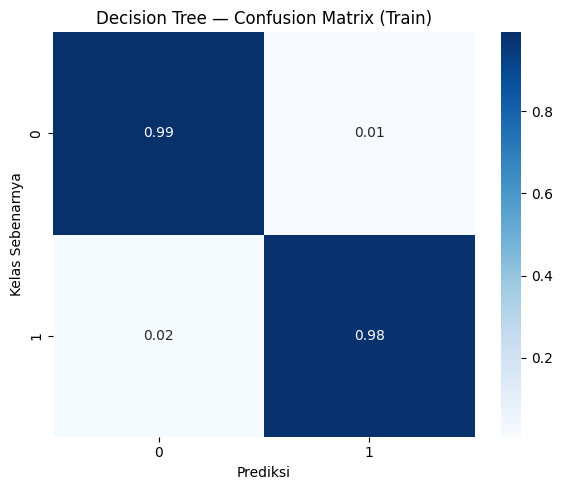

         metric  value
       accuracy 0.9900
precision_macro 0.9883
   recall_macro 0.9883
       f1_macro 0.9883
precision_micro 0.9900
   recall_micro 0.9900
       f1_micro 0.9900

=== Decision Tree: TEST ===


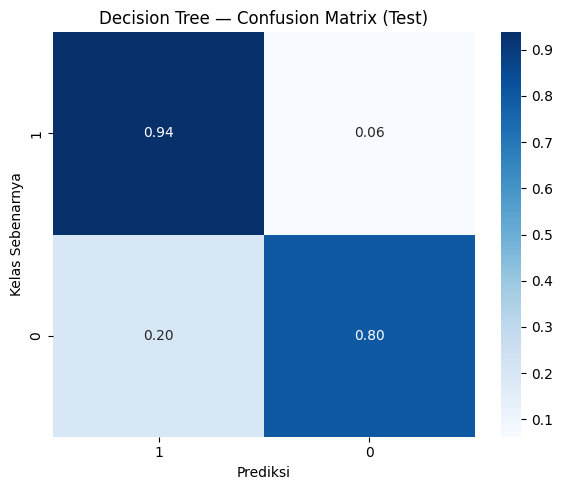

         metric  value
       accuracy 0.8431
precision_macro 0.8237
   recall_macro 0.8688
       f1_macro 0.8322
precision_micro 0.8431
   recall_micro 0.8431
       f1_micro 0.8431

=== Random Forest: TRAIN ===


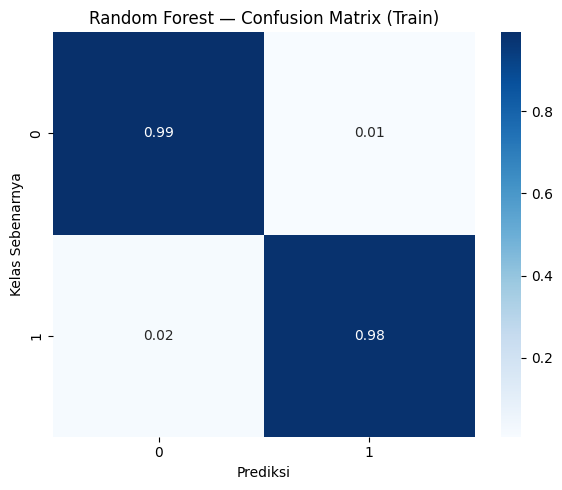

         metric  value
       accuracy 0.9900
precision_macro 0.9883
   recall_macro 0.9883
       f1_macro 0.9883
precision_micro 0.9900
   recall_micro 0.9900
       f1_micro 0.9900

=== Random Forest: TEST ===


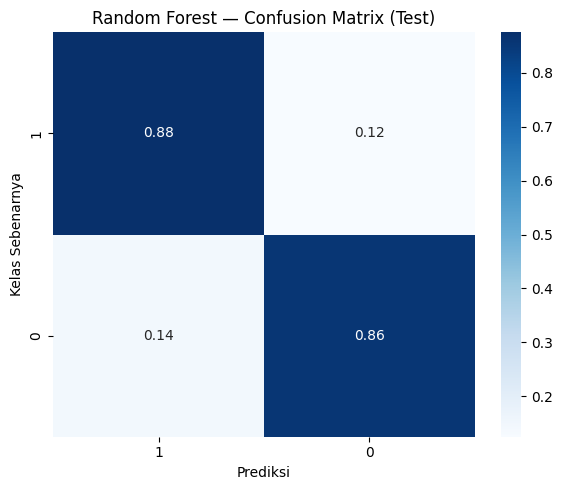

         metric  value
       accuracy 0.8627
precision_macro 0.8372
   recall_macro 0.8661
       f1_macro 0.8478
precision_micro 0.8627
   recall_micro 0.8627
       f1_micro 0.8627

=== Stratified K-Fold CV (Decision Tree) ===
Fold 1/5: acc=0.8293, f1_macro=0.8133
Fold 2/5: acc=0.9268, f1_macro=0.9172
Fold 3/5: acc=0.9500, f1_macro=0.9405
Fold 4/5: acc=0.8718, f1_macro=0.8528
Fold 5/5: acc=0.9231, f1_macro=0.9150

Cross-Validation Summary (Mean ± SD)
Accuracy   : 0.9002 ± 0.0489
F1_macro: 0.8878 ± 0.0528

=== Stratified K-Fold CV (Random Forest) ===
Fold 1/5: acc=0.9024, f1_macro=0.8915
Fold 2/5: acc=0.9268, f1_macro=0.9172
Fold 3/5: acc=0.9500, f1_macro=0.9405
Fold 4/5: acc=0.8974, f1_macro=0.8796
Fold 5/5: acc=0.9487, f1_macro=0.9423

Cross-Validation Summary (Mean ± SD)
Accuracy   : 0.9251 ± 0.0248
F1_macro: 0.9142 ± 0.0283


In [179]:
# --------------------------------------------------------
# === Cara pakai di notebookmu (TRAIN vs TEST + CV) ===
# --------------------------------------------------------

print("\n=== Decision Tree: TRAIN ===")
metrics_tree_train = evaluate_and_plot(y_train, y_pred_tree_train,
                                       title="Decision Tree — Confusion Matrix (Train)",
                                       average='macro', normalize_cm='true')

print("\n=== Decision Tree: TEST ===")
metrics_tree_test = evaluate_and_plot(y_test, y_pred_tree_test,
                                      title="Decision Tree — Confusion Matrix (Test)",
                                      average='macro', normalize_cm='true')

print("\n=== Random Forest: TRAIN ===")
metrics_rf_train = evaluate_and_plot(y_train, y_pred_rf_train,
                                     title="Random Forest — Confusion Matrix (Train)",
                                     average='macro', normalize_cm='true')


print("\n=== Random Forest: TEST ===")
metrics_rf_test = evaluate_and_plot(y_test, y_pred_rf_test,
                                    title="Random Forest — Confusion Matrix (Test)",
                                    average='macro', normalize_cm='true')


# 3) Cross-Validation (TRAIN ONLY) — stratified, instance baru tiap fold
#    Sesuaikan builder di bawah dengan parameter modelmu.
#    Jika objek punya atribut (max_depth, dll) kamu bisa refer langsung.


def build_tree_from_existing():
    # contoh: pakai parameter dari model_tree yang sudah dibuat sebelum ini
    return TreeEnsemble(
        mode="single",
        max_depth=getattr(model_tree, "max_depth", 7),
        criterion=getattr(model_tree, "criterion", "entropy"),
        min_samples_split=getattr(model_tree, "min_samples_split", 2),
        min_samples_leaf=getattr(model_tree, "min_samples_leaf", 1),
        min_impurity_decrease=getattr(model_tree, "min_impurity_decrease", 0.0),
        random_state=42,
        feature_names=getattr(model_tree, "feature_names", None)
    )


def build_rf_from_existing():
    return TreeEnsemble(
        mode="ensemble",
        n_trees=getattr(model_rf, "n_trees", 100),
        max_depth=getattr(model_rf, "max_depth", 7),
        sample_ratio=getattr(model_rf, "sample_ratio", 0.8),
        feature_ratio=getattr(model_rf, "feature_ratio", 0.5),
        criterion=getattr(model_rf, "criterion", "gini"),
        min_samples_split=getattr(model_rf, "min_samples_split", 2),
        min_samples_leaf=getattr(model_rf, "min_samples_leaf", 1),
        min_impurity_decrease=getattr(model_rf, "min_impurity_decrease", 0.0),
        random_state=42,
        feature_names=getattr(model_rf, "feature_names", None)
    )


print("\n=== Stratified K-Fold CV (Decision Tree) ===")
cv_tree = cross_val_evaluate(X_train, y_train, build_tree_from_existing, k=5, average='macro', random_state=42)


print("\n=== Stratified K-Fold CV (Random Forest) ===")
cv_rf = cross_val_evaluate(X_train, y_train, build_rf_from_existing, k=5, average='macro', random_state=42)


### 1. Evaluation Metric

In [180]:
def confusion_matrix_manual(y_true, y_pred):
    TP = sum((y_true == 1) & (y_pred == 1))
    TN = sum((y_true == 0) & (y_pred == 0))
    FP = sum((y_true == 0) & (y_pred == 1))
    FN = sum((y_true == 1) & (y_pred == 0))
    return TP, TN, FP, FN

def evaluate_model(y_true, y_pred, no_duplicate_name="No_duplicate"):
    TP, TN, FP, FN = confusion_matrix_manual(y_true, y_pred)

    accuracy  = (TP + TN) / (TP + TN + FP + FN)
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall    = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1_score  = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    print(f"\n=== Evaluasi {no_duplicate_name} ===")
    print(f"True Positive : {TP}")
    print(f"True Negative : {TN}")
    print(f"False Positive: {FP}")
    print(f"False Negative: {FN}")
    print(f"Akurasi  : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-Score : {f1_score:.4f}")
    
    return {"Accuracy": accuracy, "Precision": precision, "Recall": recall, "F1": f1_score}

#### *a. Training Model*

In [181]:
metrics_train = evaluate_model(y_train, y_pred_tree_train, "Training")


=== Evaluasi Training ===
True Positive : 61
True Negative : 137
False Positive: 1
False Negative: 1
Akurasi  : 0.9900
Precision: 0.9839
Recall   : 0.9839
F1-Score : 0.9839


#### *b. Testing Model*

In [182]:
metrics_test = evaluate_model(y_test, y_pred_tree_test, "Testing")


=== Evaluasi Testing ===
True Positive : 15
True Negative : 28
False Positive: 7
False Negative: 1
Akurasi  : 0.8431
Precision: 0.6818
Recall   : 0.9375
F1-Score : 0.7895


### 2. Confusion Matrix

### *a. Training Model*

In [183]:
def plot_confusion_matrix_train(y_true, y_pred, model_name="Model"):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    # Buat confusion matrix manual (2x2)
    cm = np.zeros((2, 2), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
    
    # Label sesuai mapping kamu: 0=Positive, 1=Negative
    labels = ['Positive (0)', 'Negative (1)']
    cm_df = pd.DataFrame(cm,
                         index=[f'Actual {lbl}' for lbl in labels],
                         columns=[f'Predicted {lbl}' for lbl in labels])
    
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', 
                cbar=False, linewidths=0.5, annot_kws={"size": 14})
    plt.title(f'{model_name} - Confusion Matrix (Training Set)', 
              fontsize=14, weight='bold')
    plt.tight_layout()
    plt.show()

### *b. Testing Model*

In [184]:
def plot_confusion_matrix_test(y_true, y_pred, model_name="Model"):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    cm = np.zeros((2, 2), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
    
    labels = ['Positive (0)', 'Negative (1)']
    cm_df = pd.DataFrame(cm,
                         index=[f'Actual {lbl}' for lbl in labels],
                         columns=[f'Predicted {lbl}' for lbl in labels])
    
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm_df, annot=True, fmt='d', cmap='Greens', 
                cbar=False, linewidths=0.5, annot_kws={"size": 14})
    plt.title(f'{model_name} - Confusion Matrix (Testing Set)', 
              fontsize=14, weight='bold')
    plt.tight_layout()
    plt.show()

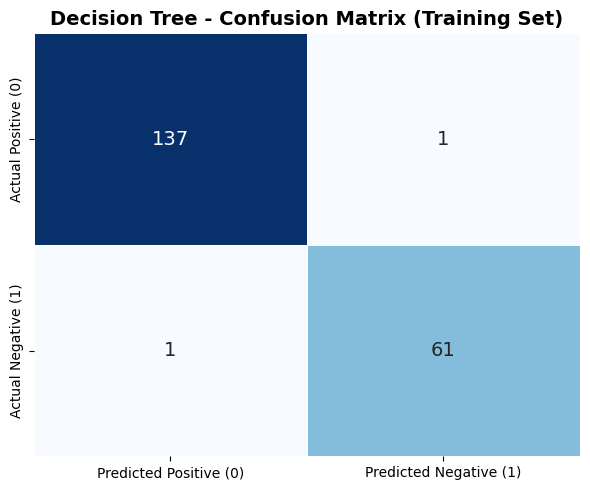

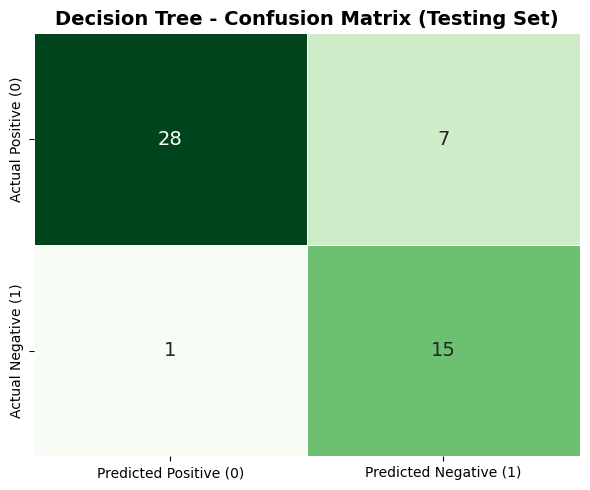

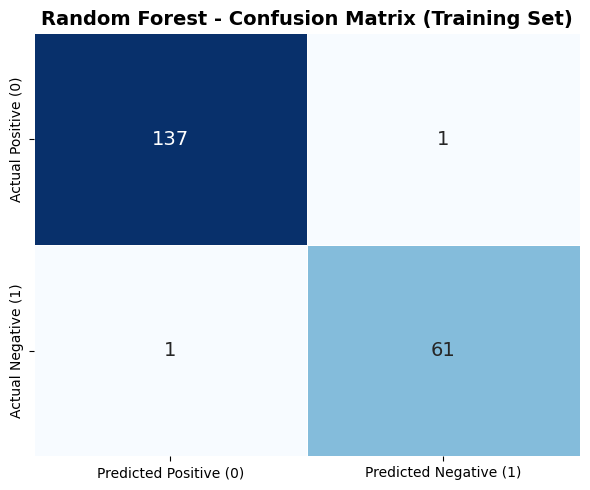

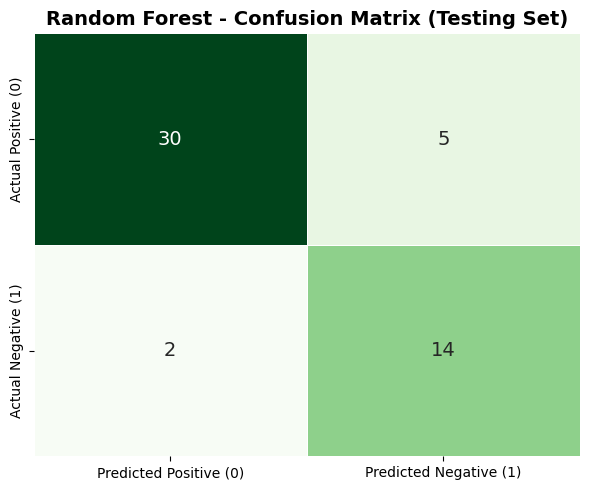

In [185]:
plot_confusion_matrix_train(y_train, y_pred_tree_train, "Decision Tree")
plot_confusion_matrix_test(y_test, y_pred_tree_test, "Decision Tree")

plot_confusion_matrix_train(y_train, y_pred_rf_train, "Random Forest")
plot_confusion_matrix_test(y_test, y_pred_rf_test, "Random Forest")

### 3. Cross Validation Bias & Variance

In [186]:
def cross_val_bias_variance(model_class, X, y, k=5, max_depth=3, min_size=5, random_state=42):
    np.random.seed(random_state)
    n = len(y)
    indices = np.arange(n)
    np.random.shuffle(indices)
    fold_size = n // k

    errors = []

    for i in range(k):
        test_idx = indices[i*fold_size:(i+1)*fold_size]
        train_idx = np.delete(indices, np.arange(i*fold_size,(i+1)*fold_size))
       
        X_train, y_train = X[train_idx], y[train_idx]
        X_test, y_test = X[test_idx], y[test_idx]
       
        # Train model baru tiap fold
        model = model_class(max_depth=max_depth, min_size=min_size)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
       
        # Hitung error (1 - akurasi)
        error = 1 - np.mean(y_pred == y_test)
        errors.append(error)


    bias = np.mean(errors)
    variance = np.var(errors)

    return bias, variance, errors

In [187]:
# bias, variance, errors = cross_val_bias_variance(DecisionTreeClassifierCustom, X, y, k=5, max_depth=3, min_size=5)

In [188]:
print("Bias (rata-rata error):", round(bias,4))
print("Variance (variasi error antar fold):", round(variance,4))
print("Error tiap fold:", [round(e,4) for e in errors])

NameError: name 'bias' is not defined

### 4. K-Fold Cross Validation

#### *a. Fungsi Cross Validation*

In [ ]:
def stratified_k_fold(X, y, model, k, avg):
    unique_classes, counts = np.unique(y, return_counts=True)
    class_indices = {cls: np.where(y == cls)[0] for cls in unique_classes}
    folds = [[] for _ in range(k)]

    for cls, indices in class_indices.items():
        np.random.shuffle(indices)
        fold_sizes = np.array_split(indices, k)
        for i in range(k):
            folds[i].extend(fold_sizes[i])

    accuracies = []

    for i in range(k):
        train_idx = np.hstack([[j] for j in range(k) if j != i])
        test_idx = np.array(folds[i])

        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        accuracy, _, _, _ = plot_confusion_matrix_test(y_test, y_pred, average=avg)
        accuracies.append(accuracy)

        print(f"Fold: {i + 1} | Accuracy: {accuracy:.2f}")

    avg_acc = np.mean(accuracies)
    std_dev = np.std(accuracies)

    print(f"Average Accuracy Between Folds: {avg_acc:.2f}")
    print(f"Total Standard Deviation: {std_dec:.2f}")
    return avg_acc, std_dev

#### *b. Model Cross Validation*

Single Mode

In [ ]:
k_fold = stratified_k_fold(X_test, y_test, model_tree, k=10, avg='macro')

TypeError: plot_confusion_matrix_test() got an unexpected keyword argument 'average'

Ensemble Mode

In [ ]:
k_fold_tree_train = stratified_k_fold(X_test, y_test, model_rf, k = 10, avg='macro')

---
Copyright @ 2025. Asta Production. All rights reserved.